In [1]:
# autoreload packages
%load_ext autoreload
%autoreload 2

# **Environmetal sound classification**


<a href="https://github.com/GianmarcoLattaruolo/Human_Data_Analytics_Project_2023/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Here we import the drive (in the case in which we are running the notebook on Colab) and prepare the environment.

In [11]:
import os
import platform
import sys
import warnings

print(sys.version)

strong_pc = platform.system() == "Linux"
in_colab = "google.colab" in sys.modules
if in_colab:
    if not os.getcwd().split("/")[-1].split("_")[-1] == "2023":
        from google.colab import drive

        drive.mount("/content/drive")
        os.chdir(r"/content/drive/MyDrive/Human_Data_Analytics_Project_2023")

    #!pip install tensorflow==2.11.0
    #!pip install tensorflow_text==2.11.0
    if not "tensorflow_io" in sys.modules:
        print("Installing tensorflow-IO")
        !pip install tensorflow-io
    if not "keras" in sys.modules and False:
        print("Installing keras")
        !pip install keras==2.11.0
    if not "scikeras" in sys.modules:
        print("Installing scikeras")
        !pip install scikeras[tensorflow]
    if not "keras-tuner" in sys.modules:
        print("installing keras tuner")
        !pip install keras-tuner
        !pip install numba==0.57.0



# GPU SETTINGS FOR LINUX and repressing warnings for windows. References for gpu: https://www.tensorflow.org/guide/gpu
show_gpu_activity = False
if sys.platform == "linux" and not in_colab:
    if show_gpu_activity:
        tf.debugging.set_log_device_placement(True)

    gpus = tf.config.list_physical_devices("GPU")
    if gpus:
        # Restrict TensorFlow to only allocate a part of memory on the first GPU
        try:
            tf.config.set_logical_device_configuration(
                gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=6800)]
            )
            logical_gpus = tf.config.list_logical_devices("GPU")
            print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        except RuntimeError as e:
            # Virtual devices must be set before GPUs have been initialized
            print(e)
else:
    warnings.filterwarnings("ignore", category=UserWarning)

3.13.9 (main, Oct 14 2025, 21:10:40) [Clang 20.1.4 ]


In this cell, we import the libraries employed in our study, along with various custom scripts developed to enhance code readability. These scripts are accessible within our GitHub repository, organized into three principal directories:

-   **Preprocessing**:

    Within the "Preprocessing" directory, we provide the following scripts:
    -   `data_loader.py``: This script facilitates dataset acquisition, file integrity verification, and automatic distribution of files into appropriate subfolders. Note that we will not use commands from this script in the notebook as they serve only once, during the initial setup.

    -   `exploration_plots.py`: Designed for dataset visualization and audio file spectrum analysis, this script capitalizes on the capabilities of the `librosa` library. Multiple spectrograms are generated and explored within this context.

-   **Visualization**:

    The "Visualization" directory contains the `model_plot.py` script, which incorporates various utility functions we devised to visualize model outcomes. These functions encompass the presentation of the confusion matrix, history plots, weight and latent space visualizations, comparison to show the reconstruction capabilities of the autoencoders , as well as auditory playback functions.

-   **Models**:

    Our "Models" directory encompasses the following scripts:

    -   `basic_ml.py`: This script implements fundamental machine learning models, which are logistic regression, random forest, decision trees, k-nearest neighbors, and support vector machines. Both grid search procedures and training routines are integrated within this script to avoid a focused treatment of this non-neural model category. Indeed it's important to clarify that our primary emphasis does not lie in these basic models; rather, they are implemented for comparative reference.
    
    -   `ann_utils.py`: At the heart of our implementations lies the 'ann_utils' script. This script defines crucial functions for a wide array of tasks, such as constructing TensorFlow datasets with assorted preprocessing methodologies, creating, training, and evaluating models, as well as visualizing results. Of particular note is our exploration of grid search techniques, involving study and experimentation with two libraries: `keras-tuner` and `scikeras`.

By structuring our work in this manner, we hope to provide a clear framework for the execution, visualization, and evaluation of our methodologies. 

In [7]:
import json
import pickle
import random
import shutil
import time

# PLOT LIBRARIES
import matplotlib
import matplotlib.pyplot as plt
# BASE LIBRARIES
import numpy as np
import pandas as pd

%matplotlib inline
import IPython.display as ipd  # for the listen to audio files
import keras
import keras_tuner as kt
# AUDIO LIBRARIES
import librosa
import tensorflow as tf
from keras import layers, models
from keras.models import load_model
from keras.regularizers import L1L2
from keras.utils import plot_model as tf_plot
# DEEP LEARNING LIBRARIES
from scikeras.wrappers import KerasClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
# BASIC MACHINE LEARNING LIBRARIES
from sklearn.model_selection import GridSearchCV, LeaveOneOut, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import check_random_state

print("TensorFlow version:", tf.__version__)
print(f"keras version = {keras.__version__}")

# RANDOM SETTINGS
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
check_random_state(seed)

# OUR DEPENDENCIES (with reload to update the changes)
import importlib

# EVALUATION LIBRAIRES
from sklearn.metrics import (PrecisionRecallDisplay, RocCurveDisplay,
                             accuracy_score, auc, make_scorer,
                             precision_recall_curve,
                             precision_recall_fscore_support, precision_score,
                             recall_score, roc_curve)

from hda import constants, paths
from hda.models import ann_utils, basic_ml
from hda.preprocessing import data_loader, exploration_plots
from hda.visualization import model_plot

TensorFlow version: 2.20.0
keras version = 3.12.0


# 1 EXPLORATORY ANALYSIS

In this chapter we are going to explore the dataset and the audio files. We will also perform some basic preprocessing operations related to the Spectrum Analysis of the audio files.

In [8]:
df_ESC50 = data_loader.load_ESC50_meta()
df_ESC10 = data_loader.load_ESC10_meta()
esc10_classes = data_loader.build_target_mapping(df_ESC10)
esc10_classes

{0: 'dog',
 41: 'chainsaw',
 12: 'crackling_fire',
 40: 'helicopter',
 10: 'rain',
 20: 'crying_baby',
 38: 'clock_tick',
 21: 'sneezing',
 1: 'rooster',
 11: 'sea_waves'}

Listen to a random audio.

In [12]:
audio_type = list(esc10_classes.values())[0]
category_mask = df_ESC10["category"] == audio_type
clip_path = random.choice(list(df_ESC10["full_path"][category_mask]))
audio_data, samplerate = librosa.load(clip_path, sr=constants.SAMPLE_RATE)
print(audio_type)
ipd.Audio(data=audio_data, rate=samplerate)

dog


## 1.2 Spectrogram Analysis

Now we dig in the analysis, exploiting the natural structure of sound.
In particular we'll need the [Short-Time Fourier Transform](https://en.wikipedia.org/wiki/Short-time_Fourier_transform) and several other spectral transformations.

A segment of 40 ms has 1764 samples


/Users/lattaruolo/Personal_Files/PROJECTS/src/Human_Data_Analytics_Project_2023/hda/preprocessing/exploration_plots.py:175: UserWarning: pcen was called on complex input so phase information will be discarded. To suppress this warning, call pcen(np.abs(D)) instead.
  S_db_pcen = librosa.pcen(stft_librosa * (2**31), max_size=5)


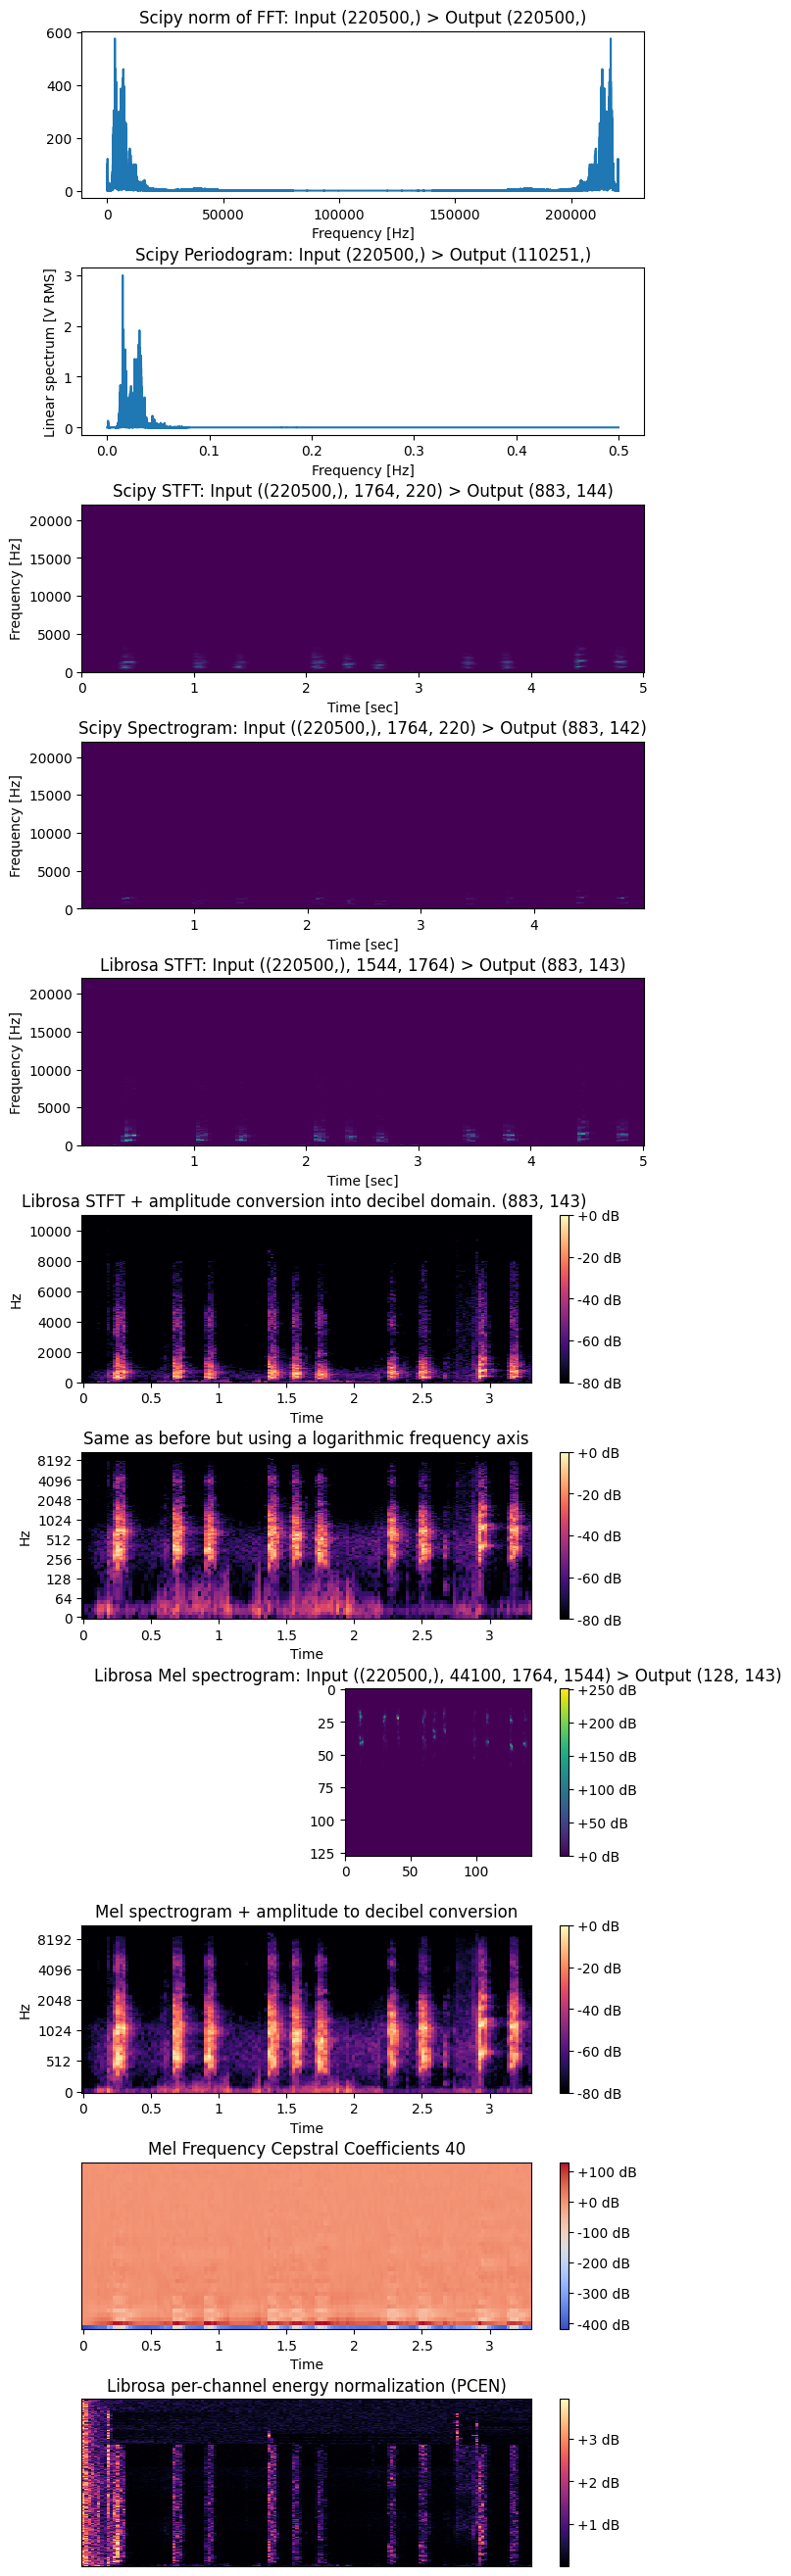

In [13]:
mfcc_audio = exploration_plots.Spectral_Analysis(
    audio_data,
    sample_rate=44100,
    segment=40,  # length of the segment in ms
    n_fft=None,  # padd the frames with zeros before DFT
    overlapping=5,
    cepstral_num=40,  # number of mel frequencies cepstral coefficients
    N_filters=50,  # number of mel filters in frequency domain
    plot=True,  # default is false
    verbose=False,  # default is false
    STFT_decibel=False,
    Mel_spectrogram_decibel=False,
    MFCC=True,
)

From the prevoius analysis we can see that the most informative plots, from a human point of view, are the one produced by using STFT, MEL or MFCC transformation of the audio. Here there are 5 plots of preprocessed audio (STFTs of audio converted into decibel domain and in logarithm scale) for each class of our dataset. Changing the preprocessing parameters we can obtain different plots.

In [ ]:
importlib.reload(importlib.import_module("Preprocessing.exploration_plots"))
from hda.preprocessing.exploration_plots import plot_clip_overview

plot_clip_overview(
    df_ESC10, preprocessing="STFT"
)  # clearly you can pass only df_ESC10 or df_ESC50

We can appreciate a ramarkable amount of intra-class similarity but also a non trascurable amount of inter-class similarity.

# 2 SUPERVISED LEARNING

In this chapter we are going to perform some supervised learning on the dataset. We will use the basic machine learning models and the neural networks. Of particular interest and not without difficulty was the creation of a routine for the dataset suitable for our purposes. In particular:
-   In the basic ML section it was sufficient for us to convert the audios into numpy arrays, which in the case of the 50-class dataset means an array of size 2000 x 220500. 
This is already beyond the limits of our ram possibilities, but can easily be solved by changing the format for saving values from float64 to float16.
-   In the section on neural networks, with a view to reusing the same function to create much larger datasets for autoencoders (up to 250000 audio as opposed to 2000 for the dataset with labels) we followed the typical processing pipeline of tensorflow, which was also shown in the course labs.

## 2.1 Basic Machine Learning

As said  before, since our interest here is not in exhaustive research ofthe best non-neuroal machine learning models, but just in having a base line for our research, we are going to build Numpy arrays with our raw audio or with the matrix of MFCC flattend (avoiding the use of other preprocessing types).

We will use this strategy to implement the following basic machine-learning models:
- Logistic Regression
- SVM
- Decision Tree and Random Forest
- KNN

We will experiment  setting a 1/4 of the dataset as test set. To understand if the 10-class dataset is actually made of classes "well separeted" we also built another 10-classes dataset (with 10 random classes among the 50 available) to have another comparison of the performance of the models.

In [ ]:
importlib.reload(importlib.import_module("Preprocessing.data_loader"))
importlib.reload(importlib.import_module("Models.basic_ml"))
importlib.reload(importlib.import_module("Visualization.model_plot"))
from Models.basic_ml import (basic_ML_experiments,
                             basic_ML_experiments_gridsearch, build_dataset,
                             extract_flatten_MFCC)
from Visualization.model_plot import confusion_matrix, listen_to_wrong_audio

from hda.preprocessing.data_loader import load_metadata

Here we create the datasets as numpy arrays.

In [ ]:
X_ESC10, y_ESC10, labels10 = build_dataset(df_ESC10)
X_ESC50, y_ESC50, labels50 = build_dataset(df_ESC50)
df_subset, X_subset, y_subset, labels_subset = build_dataset(
    df_ESC50, subset=True, num_classes=10
)  # build a dataset of num_classes classes choosen among the 50 available

This function runs several grid searches to find the best hyperparameters for the models.
The results are written in the file "grid_search_results.txt" in the "Models" folder.

In [ ]:
basic_ML_experiments_gridsearch(
    X_ESC10,
    y_ESC10,
    test_size=0.25,
    file=r"Models\grid_search_results.txt",  # where to save the results
    cv=3,  # number of fold of the cross validation
    verbose=False,
    logistic_regression=False,  # which models to run
    SVM=False,
    decision_tree=False,
    random_forest=False,
    KNN=False,
)

Now, for the different datasets created before, we trained the models with the best hyperparameters found in the grid search. The cell output concisely shows the results.

In [ ]:
results_ESC10 = basic_ML_experiments(
    X_ESC10,
    y_ESC10,
    test_size=0.25,
    MFCC=True,
    raw_audio=True,
    logistic_regression=True,
    SVM=True,
    decision_tree=True,
    random_forest=True,
    KNN=True,
)

In [ ]:
# test on 10 random classes and not with the 10 well separated of ESC10
results_subset = basic_ML_experiments(X_subset, y_subset)

In [ ]:
results_ESC50 = basic_ML_experiments(X_ESC50, y_ESC50)

Here the results are summarized in a table. We can see that the best model is the SVM, which in the next cell we are going to build and train again to show a better visualization of the results.

In [ ]:
results_ESC50

In [ ]:
# show only the best model
mfcc = 50  # 40, 30
N_filters = 160  # 80,40
C = 100  # 10, 1
kernel = "rbf"
# kernel = 'poly'
# gamma = 1
# degree = 2
test_size = 0.25
name_df = "ESC50"

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_ESC50, y_ESC50, test_size=test_size, random_state=123
)

# mfcc extraction
start_time = time.time()
X_train_mfcc = np.apply_along_axis(
    lambda x: extract_flatten_MFCC(audio=x, cepstral_num=mfcc, N_filters=N_filters),
    1,
    X_train,
)
X_test_mfcc = np.apply_along_axis(
    lambda x: extract_flatten_MFCC(audio=x, cepstral_num=mfcc, N_filters=N_filters),
    1,
    X_test,
)
print(f"Extract the MFCC requires {round(time.time()-start_time,2)} seconds.")

# fit the model
start_time = time.time()
pipe = make_pipeline(StandardScaler(), SVC(C=C, kernel=kernel, random_state=123))
pipe.fit(X_train_mfcc, y_train)
print(
    f"Fit the SVM on the {name_df} dataset with {mfcc}-MFCC and {N_filters} filters requires {round(time.time()-start_time,2)} seconds"
)

# accuracy on train and test
y_predict_train = pipe.predict(X_train_mfcc)
y_predict_test = pipe.predict(X_test_mfcc)
print(
    f"(SVM) Accuracy on {name_df} training set with {mfcc}-MFCC and {N_filters} filters. \t: {accuracy_score(y_train, y_predict_train)}"
)
print(
    f"(SVM) Accuracy on {name_df} test set with {mfcc}-MFCC and {N_filters} filters.\t: {accuracy_score(y_test, y_predict_test)}"
)

# confusion matrix
confusion_mtx = confusion_matrix(y_test, y_predict_test, labels50)

# listen to wrong audio
listen_to_wrong_audio(
    df_ESC50, y_test, y_predict_test, confusion_mtx=confusion_mtx, labels=labels50
)  # , n_audio = 2)

## 2.2 Fully Connected Neural Networks

In this section, we will proceed with the construction and training of multiple fully connected neural networks. It is important to note that our motivation for doing so is primarily comparative. This decision arises from the understanding that employing a Feedforward Neural Network (FFNN) with 220,500 variables while having only 40 samples per class is not prudent due to the limitations posed by such a scenario.

Furthermore, in the context of the dataset consisting of 50 classes, the feasibility of conducting a grid search is severely restricted. To address this, we have opted to utilize the optimal parameter configuration derived from the grid search conducted on the 10-class dataset. We intend to employ a similar approach for the majority of the subsequent models. From our perspective, this strategy is well-founded. It is based on the premise that the most suitable model configuration should remain consistent across both datasets, as it is contingent upon the inherent characteristics of the audio content rather than the quantity of classes present.

### 2.2.1 Fully connected - Raw Audio - 10 classes

In [ ]:
importlib.reload(importlib.import_module("Models.ann_utils"))
from Models.ann_utils import (K_fold_training, compile_and_fit,
                              compile_fit_evaluate, create_dataset,
                              example_batch)

The subsequent procedure will be replicated several times throughout our examination of each specific class of models and will not be commented any more:

1.  Creation of the dataset, encompassing all requisite preprocessing steps (for this instance, we utilize the raw audio data).
2.   Design and instantiation of the model, typically facilitated through a dedicated function often denoted as build_model.
3.   Execution of a Grid Search aimed at identifying the optimal hyperparameters (in this chapter we'll employ the scikeras library).
4.   Construction of the model with the most favorable hyperparameter configuration as determined by the Hyperparameter Optimization (HPO) process and subsequent training and evaluation. It is worth noting that this step will generally involve a more data than the preceding stages, especiallt in for the Autoencoder models for which we had almost 250000 audio files.

This entire procedure is executed using the ESC-10 dataset. Subsequently, for the ESC-50 dataset, steps 2 and 4 are omitted, given that the optimal hyperparameters are already established (as said before).

#### Create the dataset

In [ ]:
batch_size = 30

dataset, label = create_dataset_lite(
    df_ESC10, batch_size=batch_size, preprocessing=None, ndim=1
)
INPUT_DIM, n_labels = example_batch(dataset, label_names=list(label.columns))

#### Build the model

In [ ]:
def build_model(
    n_labels=n_labels,  # arguments to build the model
    INPUT_DIM=INPUT_DIM,
    n_units=[64],
    activation="relu",
    dropout=0.5,
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=(
        tf.keras.optimizers.Adam(learning_rate=1e-3)
        if (sys.platform == "darwin" or in_colab)
        else tf.keras.optimizers.Adam(learning_rate=1e-3)
    ),
    metrics=["accuracy"],
):

    model = tf.keras.models.Sequential(
        [tf.keras.layers.Flatten(input_shape=INPUT_DIM)], name="Flatten_ANN"
    )
    for unit in n_units:
        model.add(tf.keras.layers.Dense(unit, activation=activation))
        model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.Dense(n_labels, activation="softmax"))

    model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

    return model

#### Run a grid search to find the best params

In [ ]:
epochs = 100
patience = 20
params = {
    "n_units": [[64], [128], [64, 128], [8, 8, 16]],
    "activation": ["relu", "tanh", "elu"],
    "dropout": [0.5, 0.3, 0.1],
}
K_fold = 5

model_cv, result, best_params = K_fold_training(
    dataset,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=1,
    K=K_fold,
)

In [ ]:
# best_params = {'activation': 'relu', 'dropout': 0.3, 'n_units': [64, 128]}
print(
    "The best params are:",
    {key: value for key, value in best_params.items() if key != "INPUT_DIM"},
)

# save the best_params in pickle

with open(
    os.path.join(main_dir, "Models", "best_params_RAW_FC_10c_221.pickle"), "wb"
) as handle:
    pickle.dump(best_params, handle, protocol=pickle.HIGHEST_PROTOCOL)

#### Train the model with best HP

In [ ]:
# best_params = {'activation': 'relu', 'n_units': 64}	#best parameters from the grid search
ESC10_path = os.path.join(main_dir, "data", "ESC-10-depth")
batch_size = 30
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    ESC10_path,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    show_example_batch=True,
    verbose=0,
)

In [ ]:
model = build_model(**best_params)

epochs = 100
patience = 20
# steps_per_epoch = np.ceil(300/batch_size) #needed only if we used the repeat method
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC10,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    verbose=0,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

### 2.2.2 Fully Connected - Raw Audio - 50 classes

In [ ]:
importlib.reload(importlib.import_module("Models.ann_utils"))
from Models.ann_utils import (K_fold_training, compile_and_fit,
                              compile_fit_evaluate, create_dataset,
                              create_dataset_lite, example_batch)

#### Create the dataset

In [ ]:
# refit the model with the best parameters on the whole dataset
ESC50_path = os.path.join(main_dir, "data", "ESC-50-depth")
batch_size = 30
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    ESC50_path,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    show_example_batch=True,
    verbose=0,
)

#### Train the model

In [ ]:
model = build_model(n_labels=n_labels, **best_params)

epochs = 100
patience = 20
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC50,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    optimizer=(
        tf.keras.optimizers.Adam(learning_rate=1e-3)
        if sys.platform == "darwin"
        else tf.keras.optimizers.Adam(learning_rate=1e-3)
    ),
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

## 2.3 Convolutional Neural Networks

Within this section, we will use Convolutional Neural Networks (CNNs) for the classification of audio files. To accomplish this, we will leverage the ESC-10 dataset, subjecting the audio to three distinct preprocessing methodologies. For each preprocessing technique, we will execute a comprehensive grid search, fine-tuning the parameters to identify optimal configurations. Importantly, the parameters under consideration will remain consistent across the various preprocessing strategies. Ultimately, our aim is to conduct a comparative analysis of the outcomes obtained from these different preprocessing routes. Subsequently, we will narrow our focus to the most promising model, employing the finest preprocessing methodology, and apply it to the ESC-50 dataset for further training and evaluation. This progression ensures that our efforts are guided by a systematic exploration of preprocessing variations, leading us to the optimal model for the subsequent stages of our investigation.

### 2.3.1 CNN - STFT Preprocessed Audio

In [ ]:
importlib.reload(importlib.import_module("Models.ann_utils"))
from Models.ann_utils import (K_fold_training, compile_fit_evaluate,
                              create_dataset, create_dataset_lite)

#### Create the dataset ESC-10

In [ ]:
batch_size = 30

dataset, label = create_dataset_lite(
    df_ESC10,
    batch_size=batch_size,
    preprocessing="STFT",
    ndim=3,
)

INPUT_DIM, n_labels = example_batch(dataset, label_names=list(label.columns))

#### Build the model

We are going to keep this function for sections 2.3.2, 2.3.3 and 2.3.4 to avoid repeating the code

In [ ]:
def build_model(
    n_labels=n_labels,  # arguments to build the model
    INPUT_DIM=INPUT_DIM,
    n_units=8,
    kernel_size=(3, 3),
    activation="relu",
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    learning_rate=1e-3,
    metrics=["accuracy"],
    verbose=0,
    compile=True,
):

    model = tf.keras.models.Sequential(
        [
            # Convolutional layer 1
            tf.keras.layers.Conv2D(
                n_units,
                kernel_size,
                strides=2,
                activation=activation,
                input_shape=INPUT_DIM,
                padding="same",
            ),
            tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
            # Convolutional layer 2
            tf.keras.layers.Conv2D(
                2 * n_units, (3, 3), strides=2, activation=activation, padding="same"
            ),
            tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
            # Convolutional layer 3
            tf.keras.layers.Conv2D(
                4 * n_units, (3, 3), activation=activation, padding="same"
            ),
            tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
            # Flatten the output of the previous layer
            tf.keras.layers.Flatten(),
            # Dense layer for classification
            tf.keras.layers.Dense(
                n_labels, activation="softmax"
            ),  # Assuming 10 classes for classification
        ],
        name="CNN",
    )

    if compile:
        model.compile(
            loss=loss,
            optimizer=(
                tf.keras.optimizers.Adam(learning_rate=learning_rate)
                if sys.platform == "darwin" or in_colab
                else tf.keras.optimizers.Adam(learning_rate=learning_rate)
            ),
            metrics=metrics,
        )
        if verbose > 0:
            model.summary()

    print(
        f"n_units {n_units}, activation {activation}, learning_rate {learning_rate}, kernel size {kernel_size}"
    )

    return model

#### Run a grid search to find the best params

In [ ]:
epochs = 40
patience = 5
params = {
    "INPUT_DIM": [INPUT_DIM],
    "n_units": [16, 32],
    "activation": ["relu", "tanh"],
    "learning_rate": [1e-3, 1e-4],
    "kernel_size": [(3, 3), (5, 5)],
}
K_fold = 4

model_cv, result, best_params = K_fold_training(
    dataset,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=0,
    K=K_fold,
)

In [ ]:
print(
    "The best params are:",
    {key: value for key, value in best_params.items() if key != "INPUT_DIM"},
)

# save the best_params in pickle
with open(
    os.path.join(main_dir, "Models", "best_params_CNN_STFT_231.pickle"), "wb"
) as handle:
    pickle.dump(best_params, handle, protocol=pickle.HIGHEST_PROTOCOL)

#### Train the best model on ESC-50

In [ ]:
# refit only the best model on ESC-50
seed = 42
tf.random.set_seed(seed)
ESC50_path = os.path.join(main_dir, "data", "ESC-50-depth")
batch_size = 30
preprocessing = "STFT"

train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    ESC50_path,
    verbose=0,
    batch_size=batch_size,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing=preprocessing,  # "STFT", "MEL", "MFCC" or None
    show_example_batch=True,
    ndim=3,
)

In [ ]:
# upload the best parameters
with open(
    os.path.join(main_dir, "Models", "best_params_CNN_STFT_231.pickle"), "rb"
) as handle:
    best_params = pickle.load(handle)

In [ ]:
# build the model
model = build_model(n_labels=n_labels, compile=False, **best_params)

epochs = 50
patience = 10  # early stopping patience
lr = best_params["learning_rate"]
model, hisotry, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC50,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=(
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    ),
    metrics=["accuracy"],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

In [ ]:
# show the weights of the first layer
visualize_the_weights(model, layer_number=0, n_filters=16, verbose=0)

In [ ]:
save_model_path = os.path.join(main_dir, "Saved_Models", "ESC50_simple_CNN_STFT")
# save the model
model.save(save_model_path, save_format="keras")

#### Train the best model on augmented data

In the data_augmentation notebook starting with ESC-50 we created 20 other equally large datasets, half of them with time masks and the other half with frequency masks. Now we try to train the best model resulting from gridsearch on the augmented dataset. 

Load the already trained simple CNN STFT model which was trained on ESC-50. 

In [ ]:
# Define the path to the saved model
saved_model_path = os.path.join(main_dir, "Saved_Models", "ESC50_simple_CNN_STFT")

# Load the model
loaded_model = tf.keras.models.load_model(saved_model_path)

Duplicate it so we will be able to compare the results

In [ ]:
save_model_path = os.path.join(
    main_dir, "Saved_Models", "ESC50_simple_CNN_STFT_Augmented"
)
# save the model
loaded_model.save(save_model_path, save_format="keras")

Upload the best parameters for the model to use into the build function

In [ ]:
with open(
    os.path.join(main_dir, "Models", "best_params_CNN_STFT_231.pickle"), "rb"
) as handle:
    best_params = pickle.load(handle)

We are going to use val and test set from the ESC-50 original dataset but train is going to be a masked_dataset

In [ ]:
# refit only the best model on ESC-50
seed = 42
tf.random.set_seed(seed)
ESC50_path = os.path.join(main_dir, "data", "ESC-50-depth")
batch_size = 30
preprocessing = "STFT"

train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    ESC50_path,
    verbose=0,
    batch_size=batch_size,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing=preprocessing,  # "STFT", "MEL", "MFCC" or None
    show_example_batch=True,
    ndim=3,
)

In [ ]:
# Around 12 min to run 50 epochs on one masked dataset (we have 20)
from Models.ann_utils import create_masked_dataset

# create a log of the training or load the existing one:
log_dir = os.path.join(main_dir, "Logs_Masked")

list_masked_dataset = os.listdir(
    os.path.join(main_dir, "Saved_Datasets", "masked_dataset")
)
if ".DS_Store" in list_masked_dataset:
    list_masked_dataset.remove(".DS_Store")

for dataset_name in list_masked_dataset:
    print(f"Working on {dataset_name}")

    # stuff with the log
    if not os.path.exists(log_dir):
        os.mkdir(log_dir)
    # if log dir is empty
    if not os.listdir(log_dir):
        # create dictionary with the name of the dataset as key and False as value
        dict_dataset = {dataset: False for dataset in list_masked_dataset}
        # save the best_params in pickle
        with open(
            os.path.join(main_dir, "Logs_Masked", "dict_masked_dataset.pickle"), "wb"
        ) as handle:
            pickle.dump(dict_dataset, handle, protocol=pickle.HIGHEST_PROTOCOL)
    else:
        with open(
            os.path.join(main_dir, "Logs_Masked", "dict_masked_dataset.pickle"), "rb"
        ) as handle:
            dict_dataset = pickle.load(handle)

    # start the real training
    if not dict_dataset[dataset_name]:
        print("Training the model on the masked dataset: ", dataset_name)
        # loading the masked dataset
        dataset_path = os.path.join(
            main_dir, "Saved_Datasets", "masked_dataset", dataset_name
        )
        masked_dataset = tf.data.Dataset.load(dataset_path)

        # preprocessing into train_masked
        train_masked = create_masked_dataset(
            dataset_path, batch_size=30, normalize=True, verbose=0
        )

        # load ESC50_simple_CNN_STFT_Augmented
        saved_model_path = os.path.join(
            main_dir, "Saved_Models", "ESC50_simple_CNN_STFT_Augmented"
        )
        loaded_model = tf.keras.models.load_model(saved_model_path)

        # compile, fit and evaluate
        epochs = 50
        patience = 10  # early stopping patience
        lr = best_params["learning_rate"]

        # last folder check
        s = sum(dict_dataset.values())
        if s == len(list_masked_dataset) - 1:
            show_history = True
            show_test_evaluation = True
            show_confusion_matrix = True
            listen_to_wrong = True
        else:
            show_history = False
            show_test_evaluation = False
            show_confusion_matrix = False
            listen_to_wrong = False

        # note that the dataframe df_ESC50 does not create any problem in this framework (it is not used)
        output = compile_fit_evaluate(
            df_ESC50,
            loaded_model,
            train_masked,
            val,
            test,
            label_names,
            epochs=epochs,
            patience=patience,
            loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
            optimizer=(
                tf.keras.optimizers.Adam(learning_rate=lr)
                if sys.platform == "darwin" or in_colab
                else tf.keras.optimizers.Adam(learning_rate=lr)
            ),
            metrics=["accuracy"],
            verbose=0,
            show_history=show_history,
            show_test_evaluation=show_test_evaluation,
            show_confusion_matrix=show_confusion_matrix,
            listen_to_wrong=listen_to_wrong,
        )

        if s == len(list_masked_dataset) - 1:
            model, hisotry, confusion_mtx, evaluation = (
                output[0],
                output[1],
                output[2],
                output[3],
            )
        else:
            model, hisotry = output[0], output[1]

        # save the model
        save_model_path = os.path.join(
            main_dir, "Saved_Models", "ESC50_simple_CNN_STFT_Augmented"
        )
        model.save(save_model_path, save_format="keras")

        # update the log
        dict_dataset[dataset_name] = True

        # save the log
        with open(
            os.path.join(main_dir, "Logs_Masked", "dict_masked_dataset.pickle"), "wb"
        ) as handle:
            pickle.dump(dict_dataset, handle, protocol=pickle.HIGHEST_PROTOCOL)

    else:
        print(f"The model has already been trained on {dataset_name}")

    print("Number of masked dataset trained: ", sum(dict_dataset.values()))

In [ ]:
# show the weights of the first layer
visualize_the_weights(model, layer_number=0, n_filters=16, verbose=0)

In [ ]:
# load the dictionary
with open(
    os.path.join(main_dir, "Logs_Masked", "dict_masked_dataset.pickle"), "rb"
) as handle:
    dict_dataset_see = pickle.load(handle)

dict_dataset_see  # see if all the datasets have been trained

### 2.3.2 CNN - MEL Preprocessed Audio

In [ ]:
importlib.reload(importlib.import_module("Models.ann_utils"))
from Models.ann_utils import (K_fold_training, compile_fit_evaluate,
                              create_dataset, create_dataset_lite)

#### Create the dataset ESC-10

In [ ]:
batch_size = 30

dataset, label = create_dataset_lite(
    df_ESC10, batch_size=batch_size, preprocessing="MEL", ndim=3, verbose=0
)
INPUT_DIM, n_labels = example_batch(dataset, label_names=list(label.columns), verbose=0)

#### Run a grid search to find the best params

In [ ]:
epochs = 40
patience = 5
params = {
    "INPUT_DIM": [INPUT_DIM],
    "n_units": [16, 32],
    "activation": ["relu", "tanh"],
    "learning_rate": [1e-3, 1e-4],
    "kernel_size": [(3, 3), (7, 7)],
}
K_fold = 4

model_cv, result, best_params = K_fold_training(
    dataset,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=0,
    K=K_fold,
)

In [ ]:
print(
    "The best params are:",
    {key: value for key, value in best_params.items() if key != "INPUT_DIM"},
)

# save the best_params in pickle
with open(
    os.path.join(main_dir, "Models", "best_params_CNN_MEL_232.pickle"), "wb"
) as handle:
    pickle.dump(best_params, handle, protocol=pickle.HIGHEST_PROTOCOL)

#### Train the best model on ESC-50

In [ ]:
# refit only the best model on ESC-50
seed = 42
tf.random.set_seed(seed)
ESC50_path = os.path.join(main_dir, "data", "ESC-50-depth")
batch_size = 30
preprocessing = "MEL"

train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    ESC50_path,
    verbose=0,
    batch_size=batch_size,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing=preprocessing,  # "STFT", "MEL", "MFCC" or None
    show_example_batch=True,
    ndim=3,
)

In [ ]:
# load the best parameters
with open(
    os.path.join(main_dir, "Models", "best_params_CNN_MEL_232.pickle"), "rb"
) as handle:
    best_params = pickle.load(handle)

In [ ]:
# build the model
model = build_model(n_labels=n_labels, compile=False, **best_params)

epochs = 50
patience = 10  # early stopping patience
lr = best_params["learning_rate"]
model, hisotry, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC50,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=(
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin"
        else tf.keras.optimizers.Adam(learning_rate=lr)
    ),
    metrics=["accuracy"],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

In [ ]:
# show the weights of the first layer
visualize_the_weights(model, layer_number=0, n_filters=16, verbose=0)

In [ ]:
save_model_path = os.path.join(main_dir, "Saved_Models", "ESC50_simple_CNN_MEL")
# save the model
model.save(save_model_path, save_format="keras")

### 2.3.3 CNN - MFCC Preprocessed Audio

In [ ]:
importlib.reload(importlib.import_module("Models.ann_utils"))
from Models.ann_utils import (K_fold_training, compile_fit_evaluate,
                              create_dataset, create_dataset_lite)

#### Create the dataset ESC-10

We tested also without delta or delta-delta coefficients and the best results were achieved including both of them in the preprocessing.

In [ ]:
batch_size = 30
preprocessing = "MFCC"
delta = True
delta_delta = True
dataset, label = create_dataset_lite(
    df_ESC10,
    batch_size=batch_size,
    preprocessing=preprocessing,
    delta=delta,
    delta_delta=delta_delta,
    ndim=3,
)
INPUT_DIM, n_labels = example_batch(dataset, label_names=list(label.columns), verbose=0)

#### Run a grid search to find the best params

In [ ]:
epochs = 40
patience = 5
params = {
    "INPUT_DIM": [INPUT_DIM],
    "n_units": [64, 128],
    "activation": ["tanh"],
    "learning_rate": [1e-3, 1e-4],
    "kernel_size": [(3, 3), (7, 7)],
}
# params = {'INPUT_DIM' : [INPUT_DIM],'n_units':[64], 'activation':['relu'], 'learning_rate':[1e-3, 1e-4], 'kernel_size':[(3,3)]}
K_fold = 4

model_cv, result, best_params = K_fold_training(
    dataset,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=0,
    K=K_fold,
)

In [ ]:
print(
    "The best params are:",
    {key: value for key, value in best_params.items() if key != "INPUT_DIM"},
)

# save the best_params in pickle
with open(
    os.path.join(main_dir, "Models", "best_params_CNN_MFCC_233.pickle"), "wb"
) as handle:
    pickle.dump(best_params, handle, protocol=pickle.HIGHEST_PROTOCOL)

Here are the results of the gridsearches without delta or delta-delta

In [ ]:
# result.to_csv(os.path.join(main_dir,'Saved_Models','Simple_CNN_MFCC_all_delta_grid_search_results.csv'), index =True)
display(
    pd.read_csv(
        os.path.join(
            main_dir, "Saved_Models", "Simple_CNN_MFCC_no_delta_grid_search_results.csv"
        ),
        index_col=0,
    )
)
display(
    pd.read_csv(
        os.path.join(
            main_dir,
            "Saved_Models",
            "Simple_CNN_MFCC_only_first_delta_grid_search_results.csv",
        ),
        index_col=0,
    )
)
display(
    pd.read_csv(
        os.path.join(
            main_dir,
            "Saved_Models",
            "Simple_CNN_MFCC_all_delta_grid_search_results.csv",
        ),
        index_col=0,
    )
)

#### Train the best model on ESC-50

In [ ]:
# refit only the best model
seed = 42
tf.random.set_seed(seed)
ESC50_path = os.path.join(main_dir, "data", "ESC-50-depth")
batch_size = 30
preprocessing = "MFCC"
delta = True
delta_delta = True

train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    ESC50_path,
    verbose=0,
    batch_size=batch_size,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing=preprocessing,  # "STFT", "MEL", "MFCC" or None
    delta=delta,
    delta_delta=delta_delta,
    show_example_batch=True,
    ndim=3,
)

In [ ]:
# load the best parameters
with open(
    os.path.join(main_dir, "Models", "best_params_CNN_MFCC_233.pickle"), "rb"
) as handle:
    best_params = pickle.load(handle)

In [ ]:
# build the model
model = build_model(n_labels=n_labels, compile=False, **best_params)

epochs = 50
patience = 10  # early stopping patience
lr = best_params["learning_rate"]
model, hisotry_supervised, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC50,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=(
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin"
        else tf.keras.optimizers.Adam(learning_rate=lr)
    ),
    metrics=["accuracy"],  # ,'CategoricalAccuracy'],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

In [ ]:
# show the weights of the first layer
visualize_the_weights(model, layer_number=0, n_filters=16, verbose=0)

In [ ]:
save_model_path = os.path.join(
    main_dir, "Saved_Models", "ESC50_simple_CNN_MFCC_all_delta"
)
# save the model
model.save(save_model_path, save_format="keras")

## 2.4 Recurrent Neural Networks

In [ ]:
import importlib

importlib.reload(importlib.import_module("Models.ann_utils"))
from Models.ann_utils import (K_fold_training, compile_and_fit,
                              compile_fit_evaluate, create_dataset,
                              create_dataset_lite, example_batch)

In this section we are going to introuce several Recurrent Neural Networks (RNNs). RNNs are a class of neural networks that are able to process sequences of inputs. They are widely used in Natural Language Processing (NLP) and in other fields where the input data is sequential, like in our case. After some basic experimentation non reported in the notebook, we experienced a great vanishing gradient problematic. For this reason we resolved to use GRU recurrent units with several architectures. Again the search strategy is not different from before but this time there are a few things to notice:
-   The `build_model` function varies from paragraph to paragraph

### 2.4.1 GRU - Raw Audio reduced by 1D-Conv - 10 classes

#### Create the dataset

In [ ]:
batch_size = 30

dataset, label = create_dataset_lite(df_ESC10, batch_size=batch_size, ndim=2)
INPUT_DIM, n_labels = example_batch(dataset, label_names=list(label.columns), verbose=1)

#### Build the model

In [ ]:
def build_model(
    n_labels=n_labels,  # arguments to build the model
    INPUT_DIM=INPUT_DIM,
    n_filters=1,
    n_units=8,
    kernel_size=100,
    activation="tanh",
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    learning_rate=1e-3,
    metrics=["accuracy"],
    verbose=0,
    compile=True,
):
    strides = int(kernel_size / 2)
    model = tf.keras.Sequential(
        [
            # reduce the dimensionality of the input with a 1DConvolution
            tf.keras.layers.Conv1D(
                filters=n_filters,
                kernel_size=kernel_size,
                strides=strides,
                activation=activation,
                input_shape=INPUT_DIM,
            ),
            # with more than 1 filters I'll have prpoblems with the channel dimension not accepted by Recurrent layers
            # apply a SimpleRNN layer
            tf.keras.layers.GRU(units=n_units, activation=activation),
            tf.keras.layers.Dense(n_labels, activation="softmax"),
        ]
    )
    if compile:
        # compile the model
        model.compile(
            loss=loss,
            optimizer=(
                tf.keras.optimizers.Adam(learning_rate=learning_rate)
                if sys.platform == "darwin" or in_colab
                else tf.keras.optimizers.Adam(learning_rate=learning_rate)
            ),
            metrics=metrics,
        )
        if verbose > 0:
            model.summary()

    print(
        f"filters {n_filters}, kernel size {kernel_size}, units of GRU {n_units}, lr {learning_rate}, activation {activation}, strides {strides}"
    )
    print(f" Trainable parameters: {model.count_params()}")
    return model

#### Run a grid search to find the best params

In [ ]:
epochs = 50
patience = 10

# the grid search is too big to be implemented over all parameter space:

# Grid search for the 1DConv layer
print("FIRST GRID SEARCH")
params = {
    "n_filters": [1],
    "kernel_size": [64, 128, 256],
    "learning_rate": [1e-3, 1e-4],
}
# params = {'n_filters':[1],'kernel_size':[64], 'learning_rate':[1e-3, 1e-4]}
K_fold = 4
model_cv, result, best_params = K_fold_training(
    dataset,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=1,
    K=K_fold,
)

In [ ]:
# best_params = {'kernel_size': 128, 'learning_rate': 0.001, 'n_filters': 1} #output of first grid search
# grid search for GRU layer
print("SECOND GRID SEARCH")
params = {
    "n_units": [8, 32, 128],
    "activation": ["tanh"],
    "learning_rate": [1e-3, 1e-2],
    "n_filters": [best_params["n_filters"]],
    "kernel_size": [best_params["kernel_size"]],
}
# params = {'n_units':[8],'activation':['tanh'], 'learning_rate':[1e-3, 1e-2], 'n_filters':[best_params['n_filters']], 'kernel_size':[best_params['kernel_size']]}

K_fold = 4
model_cv, result, best_params = K_fold_training(
    dataset,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=1,
    K=K_fold,
)

In [ ]:
print(
    "The best params are:",
    {key: value for key, value in best_params.items() if key != "INPUT_DIM"},
)

# save the best_params in pickle
with open(
    os.path.join(main_dir, "Models", "best_params_RNN_raw_241.pickle"), "wb"
) as handle:
    pickle.dump(best_params, handle, protocol=pickle.HIGHEST_PROTOCOL)

#### Train the model

In [ ]:
seed = 42
tf.random.set_seed(seed)

path_to_ESC10 = os.path.join(main_dir, "data", "ESC-10-depth")

# create the dataset
batch_size = 30
preprocessing = None
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    path_to_ESC10,
    batch_size=batch_size,  # batch size
    preprocessing=preprocessing,
    verbose=0,
    show_example_batch=True,
    ndim=2,
)

In [ ]:
# We load the dictionary of the best parameters which are the MFCC ones with delta and delta_delta
with open(
    os.path.join(main_dir, "Models", "best_params_RNN_raw_241.pickle"), "rb"
) as handle:
    best_params = pickle.load(handle)

# refit only the best model
model = build_model(n_labels=n_labels, compile=False, **best_params)
learning_rate = best_params["learning_rate"]
epochs = 50
patience = 10
optimizer = (
    tf.keras.optimizers.Adam(learning_rate=learning_rate)
    if sys.platform == "darwin" or in_colab
    else tf.keras.optimizers.Adam(learning_rate=learning_rate)
)
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC10,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    metrics=["accuracy"],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

### 2.4.2 GRU - STFT Audio preprocessed - 10 classes

#### Create the dataset

In [ ]:
batch_size = 30
preprocessing = "STFT"
dataset, label = create_dataset_lite(
    df_ESC10, batch_size=batch_size, preprocessing=preprocessing, ndim=2, transpose=True
)
INPUT_DIM, n_labels = example_batch(dataset, label_names=list(label.columns), verbose=1)

#### Build the model

In [ ]:
def build_model(
    n_labels=n_labels,  # arguments to build the model
    INPUT_DIM=INPUT_DIM,
    n_units=8,
    activation="tanh",
    n_hidden_layers=1,
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    learning_rate=1e-3,
    metrics=["accuracy"],
    verbose=0,
    compile=True,
):

    # Define Simple RNN  model
    model = tf.keras.Sequential()
    model.add(
        tf.keras.layers.GRU(
            units=n_units,
            activation=activation,
            input_shape=INPUT_DIM,
            return_sequences=True if n_hidden_layers > 1 else False,
        )
    )
    if n_hidden_layers > 0:
        for i in range(1, n_hidden_layers):
            model.add(
                tf.keras.layers.GRU(
                    units=n_units * (i + 1),
                    activation=activation,
                    input_shape=INPUT_DIM,
                    return_sequences=True if i < n_hidden_layers - 1 else False,
                )
            )
    model.add(tf.keras.layers.Dense(n_labels, activation="softmax"))
    if compile:
        # compile the model
        model.compile(
            loss=loss,
            optimizer=(
                tf.keras.optimizers.Adam(learning_rate=learning_rate)
                if sys.platform == "darwin"
                else tf.keras.optimizers.Adam(learning_rate=learning_rate)
            ),
            metrics=metrics,
        )
        if verbose > 0:
            model.summary()

    print(
        f"units of GRU {n_units}, lr {learning_rate}, activation {activation}, n_hidden_layers {n_hidden_layers}"
    )

    return model

#### Run a grid search to find the best params

In [ ]:
epochs = 50
patience = 10
params = {
    "n_units": [8, 16, 32],
    "activation": ["tanh"],
    "learning_rate": [1e-3],
    "n_hidden_layers": [1, 2, 3],
}
# params = {'n_units':[8,16], 'activation':['tanh'], 'learning_rate':[1e-3], 'n_hidden_layers':[1]}

K_fold = 4

model_cv, result, best_params = K_fold_training(
    dataset,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=0,
    K=K_fold,
)

In [ ]:
print(
    "The best params are:",
    {key: value for key, value in best_params.items() if key != "INPUT_DIM"},
)

# save the best_params in pickle
with open(
    os.path.join(main_dir, "Models", "best_params_RNN_STFT_242.pickle"), "wb"
) as handle:
    pickle.dump(best_params, handle, protocol=pickle.HIGHEST_PROTOCOL)

#### Train the model

In [ ]:
# refit only the best model
# best_params = {'activation': 'tanh', 'learning_rate': 0.001, 'n_hidden_layers': 3, 'n_units': 16}
seed = 42
tf.random.set_seed(seed)

path_to_ESC10 = os.path.join(main_dir, "data", "ESC-10-depth")

# create the dataset
batch_size = 30
preprocessing = "STFT"
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    path_to_ESC10,
    batch_size=batch_size,  # batch size
    preprocessing=preprocessing,
    verbose=0,
    show_example_batch=True,
    ndim=2,
)

In [ ]:
# We load the dictionary of the best parameters which are the MFCC ones with delta and delta_delta
with open(
    os.path.join(main_dir, "Models", "best_params_RNN_STFT_242.pickle"), "rb"
) as handle:
    best_params = pickle.load(handle)

# build the model with best parameters
model = build_model(n_labels=n_labels, compile=False, **best_params)
lr = best_params["learning_rate"]
epochs = 50
patience = 10
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC10,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=(
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    ),
    metrics=["accuracy"],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

### 2.4.3 GRU - MEL Audio preprocessed - 10 classes

#### Create the dataset

In [ ]:
batch_size = 30
preprocessing = "MEL"
dataset, label = create_dataset_lite(
    df_ESC10, batch_size=batch_size, preprocessing=preprocessing, ndim=2, transpose=True
)
INPUT_DIM, n_labels = example_batch(dataset, label_names=list(label.columns), verbose=0)

#### Build the model

In [ ]:
def build_model(
    n_labels=n_labels,  # arguments to build the model
    INPUT_DIM=INPUT_DIM,
    n_units=8,
    activation="tanh",
    n_hidden_layers=1,
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    learning_rate=1e-3,
    metrics=["accuracy"],
    verbose=0,
    compile=True,
):

    # Define Simple RNN  model
    model = tf.keras.Sequential()
    model.add(
        tf.keras.layers.GRU(
            units=n_units,
            activation=activation,
            input_shape=INPUT_DIM,
            return_sequences=True if n_hidden_layers > 1 else False,
        )
    )
    if n_hidden_layers > 0:
        for i in range(1, n_hidden_layers):
            model.add(
                tf.keras.layers.GRU(
                    units=n_units * (i + 1),
                    activation=activation,
                    input_shape=INPUT_DIM,
                    return_sequences=True if i < n_hidden_layers - 1 else False,
                )
            )
    model.add(tf.keras.layers.Dense(n_labels, activation="softmax"))

    if compile:
        # compile the model
        model.compile(
            loss=loss,
            optimizer=(
                tf.keras.optimizers.Adam(learning_rate=learning_rate)
                if sys.platform == "darwin"
                else tf.keras.optimizers.Adam(learning_rate=learning_rate)
            ),
            metrics=metrics,
        )
        if verbose > 0:
            model.summary()

    print(
        f" units of GRU {n_units}, lr {learning_rate}, activation {activation}, n_hidden_layers {n_hidden_layers}"
    )

    return model

#### Run a grid search to find the best params

In [ ]:
epochs = 50
patience = 10
params = {
    "n_units": [8, 16, 32],
    "activation": ["tanh"],
    "learning_rate": [1e-3],
    "n_hidden_layers": [1, 2, 3],
}
# params = {'n_units':[8,12], 'activation':['tanh'], 'learning_rate':[1e-3], 'n_hidden_layers':[1]}

K_fold = 4

model_cv, result, best_params = K_fold_training(
    dataset,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=0,
    K=K_fold,
)

In [ ]:
print(
    "The best params are:",
    {key: value for key, value in best_params.items() if key != "INPUT_DIM"},
)

# save the best_params in pickle
with open(
    os.path.join(main_dir, "Models", "best_params_RNN_MEL_243.pickle"), "wb"
) as handle:
    pickle.dump(best_params, handle, protocol=pickle.HIGHEST_PROTOCOL)

#### Train the model

In [ ]:
# best_params = {'activation': 'tanh', 'learning_rate': 0.001, 'n_hidden_layers': 2, 'n_units': 32}

# refit only the best model
seed = 42
tf.random.set_seed(seed)
path_to_ESC10 = os.path.join(main_dir, "data", "ESC-10-depth")

# create the dataset
batch_size = 30
preprocessing = "MEL"
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    path_to_ESC10,
    batch_size=batch_size,  # batch size
    preprocessing=preprocessing,
    verbose=0,
    show_example_batch=True,
    ndim=2,
)

In [ ]:
# We load the dictionary of the best parameters which are the MFCC ones with delta and delta_delta
with open(
    os.path.join(main_dir, "Models", "best_params_RNN_MEL_243.pickle"), "rb"
) as handle:
    best_params = pickle.load(handle)

# build the model with best parameters
model = build_model(n_labels=n_labels, compile=False, **best_params)
lr = best_params["learning_rate"]
epochs = 50
patience = 10
optimizer = (
    tf.keras.optimizers.Adam(learning_rate=lr)
    if sys.platform == "darwin" or in_colab
    else tf.keras.optimizers.Adam(learning_rate=lr)
)

model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC10,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    metrics=["accuracy"],  # ,'CategoricalAccuracy'],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

### 2.4.4 GRU - MFCC Audio preprocessed - 10 classes

#### Create the dataset

In [ ]:
batch_size = 30
preprocessing = "MFCC"
delta = False
delta_delta = False
dataset, label = create_dataset_lite(
    df_ESC10,
    batch_size=batch_size,
    preprocessing=preprocessing,
    delta=delta,
    delta_delta=delta_delta,
    ndim=2,
    transpose=True,
)
INPUT_DIM, n_labels = example_batch(dataset, label_names=list(label.columns), verbose=1)

#### Build the model

In [ ]:
def build_model(
    n_labels=n_labels,  # arguments to build the model
    INPUT_DIM=INPUT_DIM,
    n_units=8,
    activation="tanh",
    order=2,  # order of the delta and delta_delta coefficients
    n_hidden_layers=1,
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    learning_rate=1e-3,
    metrics=["accuracy"],
    verbose=0,
    compile=True,
):

    # Define Simple RNN  model
    model = tf.keras.Sequential()
    # eventually starts with a layer that computes the delta and delta_delta coefficients
    if order > 0:
        model.add(MFCCWithDeltaLayer(n_mfcc=40, order=order, input_shape=INPUT_DIM))
        model.add(
            tf.keras.layers.GRU(
                units=n_units,
                activation=activation,
                return_sequences=True if n_hidden_layers > 1 else False,
            )
        )
    elif order == 0:
        model.add(
            tf.keras.layers.GRU(
                units=n_units,
                activation=activation,
                input_shape=INPUT_DIM,
                return_sequences=True if n_hidden_layers > 1 else False,
            )
        )

    if n_hidden_layers > 0:
        for i in range(1, n_hidden_layers):
            model.add(
                tf.keras.layers.GRU(
                    units=n_units * (i + 1),
                    activation=activation,
                    input_shape=INPUT_DIM,
                    return_sequences=True if i < n_hidden_layers - 1 else False,
                )
            )
    model.add(tf.keras.layers.Dense(n_labels, activation="softmax"))

    if compile:
        # compile the model
        model.compile(
            loss=loss,
            optimizer=(
                tf.keras.optimizers.Adam(learning_rate=learning_rate)
                if sys.platform == "darwin" or in_colab
                else tf.keras.optimizers.Adam(learning_rate=learning_rate)
            ),
            metrics=metrics,
        )
        if verbose > 0:
            model.summary()

    print(
        f" units of GRU {n_units}, lr {learning_rate}, activation {activation}, n_hidden_layers {n_hidden_layers}, order {order}"
    )

    return model

We split the grid search in two beacuse to use the GPU on colab the GRU cell must have tanh as activation function. Thus we tested ReLu locally and tanh on Google Colab Pro.

#### Run a grid search to find the best params


##### Activation ReLu

In [ ]:
epochs = 50
patience = 10
params = {
    "n_units": [8, 32],
    "activation": ["relu"],
    "learning_rate": [1e-3],
    "n_hidden_layers": [0, 1, 2],
    "order": [0, 1, 2],
}
# params = {'n_units':[8, 32], 'activation':['relu'], 'learning_rate':[1e-3], 'n_hidden_layers':[0],'order':[0]}

K_fold = 4

model_cv, result, best_params_relu = K_fold_training(
    dataset,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=0,
    K=K_fold,
)

##### Activation Tanh

In [ ]:
epochs = 50
patience = 10
params = {
    "n_units": [8, 32],
    "activation": ["tanh"],
    "learning_rate": [1e-3],
    "n_hidden_layers": [0, 1, 2],
    "order": [0, 1, 2],
}
# params = {'n_units':[8, 32], 'activation':['tanh'], 'learning_rate':[1e-3], 'n_hidden_layers':[0],'order':[0]}

K_fold = 4

model_cv, result, best_params_tanh = K_fold_training(
    dataset,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=0,
    K=K_fold,
)

#### Train the model

In [ ]:
print(
    "The best params are:",
    {key: value for key, value in best_params_tanh.items() if key != "INPUT_DIM"},
)

# save the best_params in pickle
with open(
    os.path.join(main_dir, "Models", "best_params_RNN_MFCC_244.pickle"), "wb"
) as handle:
    pickle.dump(best_params_tanh, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# refit only the best model
seed = 42
tf.random.set_seed(seed)
path_to_ESC10 = os.path.join(main_dir, "data", "ESC-10-depth")

# create the dataset
batch_size = 30
preprocessing = "MFCC"
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    path_to_ESC10,
    batch_size=batch_size,  # batch size
    preprocessing=preprocessing,
    delta=False,
    delta_delta=False,
    verbose=0,
    show_example_batch=True,
    ndim=2,
)

In [ ]:
# We load the dictionary of the best parameters which are the MFCC ones with delta and delta_delta
with open(
    os.path.join(main_dir, "Models", "best_params_RNN_MFCC_244.pickle"), "rb"
) as handle:
    best_params = pickle.load(handle)

model = build_model(n_labels=n_labels, compile=False, **best_params)
epochs = 100
patience = 10
lr = best_params["learning_rate"]
optimizer = (
    tf.keras.optimizers.Adam(learning_rate=lr)
    if sys.platform == "darwin" or in_colab
    else tf.keras.optimizers.Adam(learning_rate=lr)
)
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC10,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    metrics=["accuracy"],  # ,'CategoricalAccuracy'],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

### 2.4.5 GRU with STFT audio preprocessed - 50 classes

#### Create the dataset

In [ ]:
seed = 42
tf.random.set_seed(seed)
path_to_ESC10 = os.path.join(main_dir, "data", "ESC-50-depth")

# best_params = {'activation': 'tanh', 'learning_rate': 0.001, 'n_hidden_layers': 3, 'n_units': 16}

# create the dataset
batch_size = 30
preprocessing = "STFT"  # the best preprocessing by grid search

# as always for the ESC50 it is better to save the dataset for the future calls
save_train_file = os.path.join(main_dir, "Saved_Datasets", "ESC50_STFT_train")
save_val_file = os.path.join(main_dir, "Saved_Datasets", "ESC50_STFT_val")
save_test_file = os.path.join(main_dir, "Saved_Datasets", "ESC50_STFT_test")
save_labels_file = os.path.join(main_dir, "Saved_Datasets", "ESC50_STFT_labels")
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    path_to_ESC10,
    batch_size=batch_size,  # batch size
    preprocessing=preprocessing,
    verbose=0,
    show_example_batch=True,
    ndim=2,
    save_train=save_train_file,
    save_test=save_test_file,
    save_val=save_val_file,
    save_labels=save_labels_file,
)

We use the same build function used in 2.4.2 (with STFT prepocessing)

#### Build the model

In [ ]:
# We load the dictionary of the best parameters which are the MFCC ones with delta and delta_delta
with open(
    os.path.join(main_dir, "Models", "best_params_RNN_STFT_242.pickle"), "rb"
) as handle:
    best_params = pickle.load(handle)


def build_model(
    n_labels=n_labels,  # arguments to build the model
    INPUT_DIM=INPUT_DIM,
    n_units=8,
    activation="tanh",
    n_hidden_layers=1,
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    learning_rate=1e-3,
    metrics=["accuracy"],
    verbose=0,
    compile=True,
):

    # Define Simple RNN  model
    model = tf.keras.Sequential()
    model.add(
        tf.keras.layers.GRU(
            units=n_units,
            activation=activation,
            input_shape=INPUT_DIM,
            return_sequences=True if n_hidden_layers > 1 else False,
        )
    )
    if n_hidden_layers > 0:
        for i in range(1, n_hidden_layers):
            model.add(
                tf.keras.layers.GRU(
                    units=n_units * (i + 1),
                    activation=activation,
                    input_shape=INPUT_DIM,
                    return_sequences=True if i < n_hidden_layers - 1 else False,
                )
            )
    model.add(tf.keras.layers.Dense(n_labels, activation="softmax"))
    if compile:
        # compile the model
        model.compile(
            loss=loss,
            optimizer=(
                tf.keras.optimizers.Adam(learning_rate=learning_rate)
                if sys.platform == "darwin"
                else tf.keras.optimizers.Adam(learning_rate=learning_rate)
            ),
            metrics=metrics,
        )
        if verbose > 0:
            model.summary()

    print(
        f"units of GRU {n_units}, lr {learning_rate}, activation {activation}, n_hidden_layers {n_hidden_layers}"
    )

    return model


model = build_model(n_labels=n_labels, compile=False, **best_params)

#### Train the model

In [ ]:
# Train the model
epochs = 100
patience = 10
lr = best_params["learning_rate"]
optimizer = (
    tf.keras.optimizers.Adam(learning_rate=lr)
    if sys.platform == "darwin" or in_colab
    else tf.keras.optimizers.Adam(learning_rate=lr)
)
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC50,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    metrics=["accuracy"],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

### 2.4.6 GRU with MFCC audio preprocessed - 50 classes

#### Create the dataset

In [ ]:
seed = 42
tf.random.set_seed(seed)
path_to_ESC10 = os.path.join(main_dir, "data", "ESC-50-depth")

# create the dataset
batch_size = 30
preprocessing = "MFCC"  # the best preprocessing by grid search
delta = False
delta_delta = False

# as always for the ESC50 it is better to save the dataset for the future calls
save_train_file = os.path.join(main_dir, "Saved_Datasets", "ESC50_MFCC_train")
save_val_file = os.path.join(main_dir, "Saved_Datasets", "ESC50_MFCC_val")
save_test_file = os.path.join(main_dir, "Saved_Datasets", "ESC50_MFCC_test")
save_labels_file = os.path.join(main_dir, "Saved_Datasets", "ESC50_MFCC_labels")
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    path_to_ESC10,
    batch_size=batch_size,  # batch size
    preprocessing=preprocessing,
    verbose=0,
    show_example_batch=True,
    ndim=2,
    delta=delta,
    delta_delta=delta_delta,
    save_train=save_train_file,
    save_test=save_test_file,
    save_val=save_val_file,
    save_labels=save_labels_file,
)

We use the same build function used in 2.4.4 (with MFCC prepocessing)

#### Build the model

In [ ]:
# We load the dictionary of the best parameters which are the MFCC ones with delta and delta_delta
with open(
    os.path.join(main_dir, "Models", "best_params_RNN_MFCC_244.pickle"), "rb"
) as handle:
    best_params = pickle.load(handle)


def build_model(
    n_labels=n_labels,  # arguments to build the model
    INPUT_DIM=INPUT_DIM,
    n_units=8,
    activation="tanh",
    order=2,  # order of the delta and delta_delta coefficients
    n_hidden_layers=1,
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    learning_rate=1e-3,
    metrics=["accuracy"],
    verbose=0,
    compile=True,
):

    # Define Simple RNN  model
    model = tf.keras.Sequential()
    # eventually starts with a layer that computes the delta and delta_delta coefficients
    if order > 0:
        model.add(MFCCWithDeltaLayer(n_mfcc=40, order=order, input_shape=INPUT_DIM))
        model.add(
            tf.keras.layers.GRU(
                units=n_units,
                activation=activation,
                return_sequences=True if n_hidden_layers > 1 else False,
            )
        )
    elif order == 0:
        model.add(
            tf.keras.layers.GRU(
                units=n_units,
                activation=activation,
                input_shape=INPUT_DIM,
                return_sequences=True if n_hidden_layers > 1 else False,
            )
        )
    if n_hidden_layers > 0:
        for i in range(1, n_hidden_layers):
            model.add(
                tf.keras.layers.GRU(
                    units=n_units * (i + 1),
                    activation=activation,
                    input_shape=INPUT_DIM,
                    return_sequences=True if i < n_hidden_layers - 1 else False,
                )
            )
    model.add(tf.keras.layers.Dense(n_labels, activation="softmax"))

    if compile:
        # compile the model
        model.compile(
            loss=loss,
            optimizer=(
                tf.keras.optimizers.Adam(learning_rate=learning_rate)
                if sys.platform == "darwin" or in_colab
                else tf.keras.optimizers.Adam(learning_rate=learning_rate)
            ),
            metrics=metrics,
        )
        if verbose > 0:
            model.summary()

    print(
        f" units of GRU {n_units}, lr {learning_rate}, activation {activation}, n_hidden_layers {n_hidden_layers}, order {order}"
    )

    return model


model = build_model(n_labels=n_labels, compile=False, **best_params)

#### Train the model

In [ ]:
lr = best_params["learning_rate"]
optimizer = (
    tf.keras.optimizers.Adam(learning_rate=lr)
    if sys.platform == "darwin" or in_colab
    else tf.keras.optimizers.Adam(learning_rate=lr)
)
# train the model
epochs = 100
patience = 10
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC50,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    metrics=["accuracy"],  # ,'CategoricalAccuracy'],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

# 3 UNSUPERVISED LEARNING: AUTOENCODERS

The idea is to train an autoencoder on ESC-US and use only the encoder on ESC-50 as a feature extractor to then build a better performing classifier trainable on the features suggested by the encoder. 

Initially we will try to construct autoencoders with latent space flatten, later we will try with latent space tensor so that we can maintain the image structure. 

In [ ]:
import importlib

importlib.reload(importlib.import_module("Models.ann_utils"))
importlib.reload(importlib.import_module("Visualization.model_plot"))
importlib.reload(importlib.import_module("Preprocessing.data_loader"))
from Models.ann_utils import *
from Visualization.model_plot import *

from hda.preprocessing.data_loader import *

## 3.0 Dataset management

In [ ]:
# check that all files have 220500 frames and that the extensions are .ogg (removed 3 files by hand: 2 .txt and one because of frames mismatch)
path_to_check = os.path.join(main_dir, "data", "ESC-US")
target_extension = ".ogg"
target_duration = 220500  # 5 seconds

check_subfolder_files(path_to_check, target_extension, target_duration)

## 3.1 AE on raw audio - Dense FFNN

We have reached a crucial point in our thesis where we're starting to train our very first autoencoder. To kick things off, we are going with the simplest type of neural network: a dense network. It is important to keep our expectations in check because we're anticipating bad results at this stage. Also, it's worth noting that this type of training is quite resource demanding and the model might be too heavy. 

In [ ]:
folder_path = "Saved_Models"  # Replace this with the actual folder path
file_names = ["Dense_AE_ffnn_count.txt"]

for name in file_names:
    file_path = os.path.join(main_dir, folder_path, name)
    with open(file_path, "w") as f:
        f.write("0")
    print(f"Created {name} with content '0' in folder {folder_path}")

### Create the dataset

Note that we decided to normalize the data.

In [ ]:
folder_number = 1
batch_size = 16 if not strong_pc else 80
preprocessing = None
start_time = time.time()
train, val, test, INPUT_DIM = create_US_dataset(
    preprocessing=preprocessing,
    folder_number=folder_number,
    batch_size=batch_size,
    main_dir=main_dir,
    ndim=2,
)
print(f"This cell requires {round(time.time()-start_time,2)} seconds")

Here we are using only dense layers, we use the Mean squared error as metric to measure the goodnees of the autoencoding.

We need to understand something about the mse: for now it is enoght to know on average which is the mse between two audio signals. In order to have a good estimate we took the mean mse over the first batch in the training set.

In [ ]:
mse = tf.keras.losses.MeanSquaredError()
batch_mean_mse = 0

var_list = []
# Extract the first batch from the training set: x is a tuple of arrays of dim (batch_size,220500)
for x in train.take(1):
    batch_size = x[0].shape[0]
    for i in x[1]:
        for j in x[1]:
            # mse of i,j
            batch_mean_mse += mse(i, j).numpy()
            var_list.append(mse(i, j))
    break

batch_mean_mse /= batch_size**2

print(
    f"mean MSE between two random audio signals in the first batch: {batch_mean_mse:.5f}"
)
# mean MSE between two random audio signals in the first batch: 0.03532

print("The variance of the MSEs is {:.5f}".format(np.var(var_list)))

### Preparation to use Keras-Tuner

Useful links:
- [Getting_started](https://keras.io/guides/keras_tuner/getting_started/)
- [Tailor_the_Search_Space](https://keras.io/guides/keras_tuner/tailor_the_search_space/)
- [Keras_Tuner_API](https://keras.io/api/keras_tuner/)

In [ ]:
INPUT_DIM = (220500, 1)


def build_autoencoder(
    INPUT_DIM=INPUT_DIM,
    code_size=32,
    activation="tanh",
    n_layers=1,
    n_units_list=[128],
    dropout=0.0,
    batch_norm=True,
    learning_rate=1e-3,
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=["mse"],
):

    # INPUT: array_shape = shape of the single audio np array in the dataset: (220500,); code_size = number of neurons in the last dense layer of the encoder
    # OUTPUT: encoder and decoder models
    if n_layers is None:
        n_layers = len(n_units_list)

    # check if the n_units_list is coherent with n_layers
    if len(n_units_list) != n_layers:
        print("n_units_list must have the same length as n_layers!")
        n_layers = len(n_units_list)

    # check if the list is in decreasing order
    if n_units_list != sorted(n_units_list, reverse=True):
        print("The list of units must be in decreasing order!")
        n_units_list = sorted(n_units_list, reverse=True)

    # Encoder
    encoder = tf.keras.Sequential()
    encoder.add(tf.keras.Input(INPUT_DIM))
    encoder.add(layers.Flatten())

    for i in range(n_layers):
        encoder.add(layers.Dense(n_units_list[i], activation=activation))
        if batch_norm:
            encoder.add(layers.BatchNormalization())
        if dropout > 0:
            encoder.add(layers.Dropout(dropout))

    encoder.add(layers.Dense(code_size, activation=activation))

    # Decoder
    decoder = tf.keras.Sequential()
    decoder.add(
        tf.keras.Input(
            code_size,
        )
    )

    for i in range(n_layers):
        decoder.add(layers.Dense(n_units_list[-i - 1], activation=activation))
        if batch_norm:
            decoder.add(layers.BatchNormalization())
        if dropout > 0:
            decoder.add(layers.Dropout(dropout))

    decoder.add(layers.Dense(np.prod(INPUT_DIM)))
    decoder.add(layers.Reshape(INPUT_DIM))

    # build the autoencoder with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    reconstruction = decoder(code)
    autoencoder = tf.keras.Model(
        inputs=inp, outputs=reconstruction, name="Autoencoder_ffnn"
    )

    # compile the autoencoder
    lr = learning_rate
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )
    loss = loss
    metrics = metrics

    autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    # print the number of trainable parameters
    print(
        f"Model built with { sum(tf.keras.backend.count_params(p) for p in autoencoder.trainable_variables)} trainable params"
    )

    return autoencoder

In [ ]:
verbose = 2
# test the build_autoencoder function
autoencoder = build_autoencoder(n_layers=2, n_units_list=[64, 32])
if verbose > 1:
    autoencoder.summary(line_length=100)
    autoencoder.layers[1].summary(line_length=100)
    autoencoder.layers[2].summary(line_length=100)

In [ ]:
# function to build the model using different hyperparameters (keras tuner code)


def build_model(hp, test=False):

    # define the hyperparameters
    if test:
        print("Running a smaller grid search as a test")
        code_size = hp.Choice(name="code_size", values=[32, 64])
        activation = "tanh"
        n_layers = 1
        list_of_n_units_list = [[], [64]]
        n_units_list = list_of_n_units_list[
            hp.Int(
                name="n_units_list",
                min_value=0,
                max_value=len(list_of_n_units_list) - 1,
                step=1,
                sampling="linear",
            )
        ]
        dropout = 0.0
        batch_norm = hp.Boolean("batch_norm", default=True)
        learning_rate = 1e-3
    else:
        code_size = hp.Choice(name="code_size", values=[8, 16, 32], default=32)
        list_of_n_units_list = [[32], [32, 16], [64, 32, 16]]
        n_units_list = list_of_n_units_list[
            hp.Int(
                name="n_units_list",
                min_value=0,
                max_value=len(list_of_n_units_list) - 1,
                step=1,
                sampling="linear",
            )
        ]
        n_layers = None
        activation = hp.Choice(
            name="activation", values=["relu", "tanh", "elu"], default="tanh"
        )
        dropout = hp.Choice(name="dropout", values=[0.0, 0.2, 0.5], default=0.0)
        batch_norm = hp.Boolean("batch_norm", default=True)
        learning_rate = hp.Choice(
            "learning_rate",
            values=[1e-4, 1e-3, 5 * 1e-3, 1e-2, 5 * 1e-2, 1e-1],
            default=1e-3,
        )

    # define the model
    model = build_autoencoder(
        n_units_list=n_units_list,
        code_size=code_size,
        activation=activation,
        n_layers=n_layers,
        dropout=dropout,
        batch_norm=batch_norm,
        learning_rate=learning_rate,
    )

    return model

In [ ]:
# test the build_model function
build_model(kt.HyperParameters()).summary()

### Implement the grid search hyperparamter-wise

In [ ]:
# dictionary with the default values of the hyperparams to be update each time
default_values = {
    "code_size": 32,
    "activation": "tanh",
    "n_units_list": 0,  # 0, 1 or 2 corresponding to the index of  [[32], [32, 16], [64, 32, 16]]
    "dropout": 0.0,
    "batch_norm": True,
    "learning_rate": 1e-3,
}

key_list = list(default_values.keys())

# define the general variables for our tuner
hpo_methods = ["RandomSearch", "BayesianOptimization", "Hyperband"]
max_model_size = 3 * 10**7  # only 10**7 exclude almost all the models
max_trials = 10
dir_name = os.path.join(main_dir, "Dense_AE_ffnn")
verbose = 0

# define a smaller dataset for the grid search
if strong_pc:
    train_small = train
    val_small = val
else:
    small_size_dataset = 400
    train_val_small = train.unbatch().take(small_size_dataset)
    train_small = train_val_small.skip(100).batch(25)
    val_small = train_val_small.take(100).batch(25)

# define a list to collect all the best scores
best_score_dict = {
    "RandomSearch": [],
    "BayesianOptimization": [],
    "Hyperband": [],
}  # we hope to have a decreasing list of numbers...

# to be consistent with this type of grid search we should pass each hp more than one time...
for hpo_method in hpo_methods:
    random.shuffle(key_list)
    for hyper_params in key_list:
        print(f"Searching for the best value for {hyper_params}")

        # define an hp set with all fix but one
        hp = kt.HyperParameters()

        for fixed_param in default_values.keys():
            if fixed_param != hyper_params:
                value = default_values[fixed_param]
                if isinstance(value, list):
                    for idx, v in enumerate(value):
                        hp.Fixed(name=f"{fixed_param}_{idx}", value=v)
                else:
                    hp.Fixed(name=fixed_param, value=value)

        if verbose > 1:
            display(hp.space)

        # create a tuner for the params not fixed
        tuner = build_tuner(
            build_model=build_model,
            hpo_method=hpo_method,
            max_model_size=max_model_size,
            max_trials=max_trials,
            dir_name=dir_name,
            overwrite=True,
            objective=kt.Objective("val_mse", direction="min"),
            hp=hp,
            not_fixed_param=hyper_params,
            tune_new_entries=True,
        )

        if verbose > 2:
            display(tuner.search_space_summary(extended=True))

        # fit the tuner
        epochs = (
            10 if not strong_pc else 50
        )  # we can use a small number of epochs for the grid search
        patience = 10 if not strong_pc else 20
        metrics = ["mse"]
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_" + metrics[0], verbose=verbose, patience=patience
            )
        ]

        tuner.search(
            train_small,
            validation_data=val_small,
            callbacks=callbacks,
            epochs=epochs,
            verbose=int(verbose > 0),
        )

        # retrive the best value for the free hp
        best_value = tuner.get_best_hyperparameters()[0].values[hyper_params]

        # retrive the best score reached
        best_score = tuner.get_best_models(num_models=1)[0].evaluate(
            val, return_dict=True
        )["mse"]

        print(
            f"The best value for {hyper_params} is {best_value}, the best score is {best_score}"
        )
        best_score_dict[hpo_method].append(best_score)

        # update the default dict of values
        default_values[hyper_params] = best_value

        # save the updated dictionary
        file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
        with open(file_path, "wb") as file:
            pickle.dump(default_values, file)

        # delete the folder just created by the run
        shutil.rmtree(os.path.join(main_dir, dir_name, hpo_method + "_" + hyper_params))

    with open(file_path, "rb") as file:
        best_params = pickle.load(file)

    display(best_params)


# save the best_score_dict
file_path = os.path.join(main_dir, dir_name, "best_scores")
with open(file_path, "wb") as file:
    pickle.dump(best_score_dict, file)

with open(file_path, "rb") as file:
    best_scores = pickle.load(file)

display(best_scores)

In [ ]:
# compare the best hp from the 3 grid search methods
hyperparamters = []
for hpo_method in ["RandomSearch", "BayesianOptimization", "Hyperband"]:
    file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
    with open(file_path, "rb") as file:
        hyperparamters.append(pickle.load(file))
pd.DataFrame(
    hyperparamters, index=["RandomSearch", "BayesianOptimization", "Hyperband"]
)

### Train the model with the best params on more data

In [ ]:
best_params = {
    "n_units_list": [64, 32, 16],
    "code_size": 16,
    "activation": "relu",
    "dropout": 0.2,
    "batch_norm": False,
    "learning_rate": 0.001,
}

# build an autoencoder with the best params
autoencoder = build_autoencoder(**best_params)

# autoencoder = tuner.get_best_models(num_models=1)[0] #to create the model with some already quite good weights
autoencoder.summary()
verbose = 0
if verbose > 0:
    autoencoder.layers[1].summary()
    autoencoder.layers[2].summary()
epochs = 1 if not strong_pc else 100
n_folders = (
    2 if not strong_pc else 125
)  # then you can restart and train on more folders
patience = 10
autoencoder = US_training(
    AE_name="Dense_AE_ffnn",
    autoencoder=autoencoder,
    epochs=epochs,
    n_folders=n_folders,
    patience=patience,
    verbose=0,
)

### Show the reconstruction capabilities of the model

In [ ]:
# load the saved model
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", "Dense_AE_ffnn")
)
model_loaded.summary()

# plot the original and reconstructed
plot_original_reconstructed_raw(model=model_loaded, n_figures=5, test=test)

## 3.2 Autoencoder on preprocessed audio MFCC - Convolutional and flatten code

As we have seen before the MEL preprocessing is always beaten by one of the other two. For this reason we are going to avoid this type of computations and we will train the autoencoder to reconstruct the MFCC or the STFT only.

### Create the dataset

In [ ]:
preprocessing = "MFCC"
AE_name = "AE_Conv_prep_flatten_" + preprocessing
train, val, test, INPUT_DIM = create_US_dataset(
    preprocessing=preprocessing,
    folder_number=1,
    main_dir=main_dir,
)

In [ ]:
folder_path = "Saved_Models"  # Replace this with the actual folder path
file_names = [AE_name + "_count.txt"]

for name in file_names:
    file_path = os.path.join(main_dir, folder_path, name)
    with open(file_path, "w") as f:
        f.write("0")
    print(f"Created {name} with content '0' in folder {folder_path}")

To interpret the mean squared error the we are going to optimize in our training we need to compute some mse between our images and some random images or between couple of images in our training set.

In [ ]:
mse = tf.keras.losses.MeanSquaredError()

# Extract the first batch from the training set: x is a tuple of arrays of dim (128,220500)
for x, y in train.take(1):
    # compute the mse between the first batch and a batch of random images with the same shape
    random_images_1 = tf.random.uniform(
        shape=x.shape, minval=-1, maxval=1, dtype=tf.float32
    )
    random_images_2 = np.random.uniform(-1, 1, size=x.shape)
    print(
        f"Mean MSE between an audio preprocessed and a random image (tf) : {mse(x, random_images_1):.5f}"
    )
    print(
        f"Mean MSE between an audio preprocessed and a random image (np): {mse(x, random_images_2):.5f}"
    )
    print(
        f"Mean MSE between two random images (tf-np): {mse(random_images_1, random_images_2):.5f}"
    )

### Preparation to use Keras-Tuner

Now we define a function to build a generic convolutional autoencoder. We'll give this function to a keras tuner.

In [ ]:
# General function to build an autoencoder
# CONVOLUTIONAL AUTOENCODER WITH VECTORIAL CODE
code_size = 32
n_layers = 2
n_units = 32


# the real build function for general autoencoder (keras code)
def build_autoencoder(
    img_shape=INPUT_DIM,
    code_size=code_size,
    activation="tanh",
    padding="valid",
    n_layers=n_layers,  # max number of layers is 3
    n_units=n_units,
    kernel_size=(3, 3),
    strides=(2, 2),
    max_pooling=(2, 2),
    regularizer=1e-4,
    batch_norm=True,
    drop_out=0.0,
    learning_rate=1e-3,
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=["mse"],
    AE_name=AE_name,
):
    lr = learning_rate
    # encoder
    encoder = tf.keras.Sequential(name="Encoder")
    encoder.add(tf.keras.Input(img_shape))
    for i in range(n_layers):
        encoder.add(
            layers.Conv2D(
                n_units * (i + 1),
                kernel_size,
                strides=strides,
                activation=activation,
                padding=padding,
            )
        )
        encoder.add(layers.MaxPool2D(max_pooling, padding="same"))
        if batch_norm:
            encoder.add(layers.BatchNormalization())
        if drop_out > 0:
            encoder.add(layers.Dropout(drop_out))

    # flatten layer to get the code
    my_shape = encoder.layers[-1].output_shape
    encoder.add(layers.Flatten())
    encoder.add(
        layers.Dense(
            code_size,
            activation=activation,
            activity_regularizer=keras.regularizers.l1(regularizer),
        )
    )

    # decoder
    decoder = tf.keras.Sequential(name="Decoder")
    decoder.add(tf.keras.Input(code_size))
    decoder.add(layers.Dense(np.prod(my_shape[1:]), activation=activation))
    decoder.add(layers.Reshape(my_shape[1:]))

    # transpose convolutions
    for i in range(n_layers):
        filters = n_units * (n_layers - i) if i < n_layers - 1 else 1
        decoder.add(
            layers.Conv2DTranspose(
                filters,
                kernel_size,
                strides=strides,
                activation=activation,
                padding=padding,
            )
        )
        decoder.add(layers.UpSampling2D(size=max_pooling))
        if batch_norm:
            decoder.add(layers.BatchNormalization())

    # final reshape
    decoder.add(
        tf.keras.layers.Resizing(
            height=INPUT_DIM[0],
            width=INPUT_DIM[1],
            interpolation="bilinear",
            crop_to_aspect_ratio=False,
        )
    )

    # build the autoencoder with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    reconstruction = decoder(code)
    autoencoder = tf.keras.Model(inputs=inp, outputs=reconstruction, name=AE_name)

    # compile the autoencoder
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )
    loss = loss
    metrics = metrics

    autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    # print the number of trainable parameters
    print(
        f"Model built with { sum(tf.keras.backend.count_params(p) for p in autoencoder.trainable_variables)} trainable params"
    )

    return autoencoder

In [ ]:
verbose = 0
# test the build_autoencoder function
autoencoder = build_autoencoder(n_layers=3)
if verbose > 1:
    autoencoder.summary(line_length=100)
    autoencoder.layers[1].summary(line_length=100)
    autoencoder.layers[2].summary(line_length=100)

In [ ]:
# function to build the model using different hyperparameters (keras tuner code)


def build_model(hp, test=False):

    # define hyperparameters
    if test:  # if test is true you run the tuner only on a reduced hyperparameter space
        print("Running a test smaller grid search")
        n_units = 32
        n_layers = hp.Choice(name="n_layers", values=[2, 3])
        kernel_size = 3
        strides = 2
        max_pooling = 2
        regularizer = hp.Choice(name="regularizer", values=[1e-4, 0.0])
        padding = "same"
        code_size = 32
        activation = "tanh"
        drop_out = hp.Choice(name="drop_out", values=[0.25, 0.0])
        batch_norm = True
        lr_max, lr_min = 1e-3, 1e-3
        hp_lr = hp.Float(
            "learning_rate", min_value=lr_min, max_value=lr_max, sampling="log"
        )
    else:
        n_units = hp.Choice(name="n_units", values=[4, 8, 16, 32, 64, 128], default=32)
        n_layers = hp.Int(
            name="n_layers",
            min_value=1,
            max_value=3,
            step=1,
            sampling="linear",
            default=2,
        )
        kernel_size = hp.Choice(name="kernel_size", values=[3, 5, 7], default=3)
        strides = hp.Choice(name="strides", values=[2, 3], default=2)
        max_pooling = hp.Choice(name="max_pooling", values=[2, 3], default=2)
        regularizer = hp.Choice(
            name="regularizer", values=[0.0, 1e-2, 1e-3, 1e-4, 1e-5], default=1e-4
        )
        padding = hp.Choice(name="padding", values=["same", "valid"], default="valid")
        code_size = hp.Choice(name="code_size", values=[32, 64, 128], default=32)
        activation = hp.Choice(
            name="activation", values=["relu", "elu", "tanh"], default="tanh"
        )
        drop_out = hp.Choice(name="drop_out", values=[0.0, 0.25, 0.5], default=0.0)
        batch_norm = hp.Choice(name="batch_norm", values=[True, False], default=True)
        lr_min, lr_max = 1e-4, 1e-1
        learning_rate = hp.Choice(
            "learning_rate",
            values=[1e-4, 1e-3, 5 * 1e-3, 1e-2, 5 * 1e-2, 1e-1],
            default=1e-3,
        )

    model = build_autoencoder(
        code_size=code_size,
        activation=activation,
        padding=padding,
        n_layers=n_layers,
        n_units=n_units,
        kernel_size=(kernel_size, kernel_size),
        strides=(strides, strides),
        max_pooling=(max_pooling, max_pooling),
        regularizer=regularizer,
        batch_norm=batch_norm,
        drop_out=drop_out,
        learning_rate=learning_rate,
    )

    return model

In [ ]:
# test the build_model function
build_model(kt.HyperParameters()).summary()

### Implement the grid search hyperparamter-wise

In [ ]:
# dictionary with the default values of the hyperparams to be update each time
default_values = {
    "n_layers": 2,
    "n_units": 32,
    "kernel_size": 3,
    "strides": 2,
    "max_pooling": 2,
    "regularizer": 0.0,
    "padding": "valid",
    "code_size": 32,
    "activation": "tanh",
    "drop_out": 0.0,
    "batch_norm": True,
    "learning_rate": 1e-3,
}

key_list = list(default_values.keys())

# define the general variables for our tuner
hpo_methods = ["RandomSearch", "BayesianOptimization", "Hyperband"]
problematic_combination = []
max_model_size = 10**6
max_trials = 10
dir_name = AE_name
verbose = 0

if strong_pc:
    train_small = train
    val_small = val
else:
    small_size_dataset = 40
    train_val_small = train.unbatch().take(small_size_dataset)
    train_small = train_val_small.skip(10).batch(25)
    val_small = train_val_small.take(10).batch(25)

# define a list to collect all the best scores
best_score_dict = {"RandomSearch": [], "BayesianOptimization": [], "Hyperband": []}

# to be consistent with this type of grd search we should pass each hp more than one time...
for hpo_method in hpo_methods:
    random.shuffle(key_list)
    for hyper_params in key_list:
        print(f"Searching for the best value for {hyper_params}")

        # define an hp set with all fix but one
        hp = kt.HyperParameters()

        for fixed_param in default_values.keys():
            if fixed_param != hyper_params:
                hp.Fixed(name=fixed_param, value=default_values[fixed_param])

        if verbose > 1:
            display(hp.space)

        try:
            # create a tuner for the params not fixed
            tuner = build_tuner(
                build_model=build_model,
                hpo_method=hpo_method,
                max_model_size=max_model_size,
                max_trials=max_trials,
                dir_name=dir_name,
                overwrite=True,
                objective=kt.Objective("val_mse", direction="min"),
                hp=hp,
                not_fixed_param=hyper_params,
                tune_new_entries=True,
            )

            if verbose > 2:
                display(tuner.search_space_summary(extended=True))

            # fit the tuner
            epochs = 50
            patience = 10
            metrics = ["mse"]
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_" + metrics[0], verbose=verbose, patience=patience
                )
            ]

            tuner.search(
                train_small,
                validation_data=val_small,
                callbacks=callbacks,
                epochs=epochs,
                verbose=int(verbose > 0),
            )

            # retrive the best value for the free hp
            best_value = tuner.get_best_hyperparameters()[0].values[hyper_params]

            # retrive the best score reached
            best_score = tuner.get_best_models(num_models=1)[0].evaluate(
                val, return_dict=True
            )["mse"]

            print(
                f"The best value for {hyper_params} is {best_value}, the best score is {best_score}"
            )
            best_score_dict[hpo_method].append(best_score)

            # update the default dict of values
            default_values[hyper_params] = best_value

            # save the updated dictionary
            file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
            with open(file_path, "wb") as file:
                pickle.dump(default_values, file)

            # delete the folder just created by the run
            shutil.rmtree(
                os.path.join(main_dir, dir_name, hpo_method + "_" + hyper_params)
            )

        except:
            problematic_combination.append(
                ("search_for" + hyper_params, default_values)
            )

    with open(file_path, "rb") as file:
        best_params = pickle.load(file)

    display(best_params)

# save the best_score_dict
file_path = os.path.join(main_dir, dir_name, "best_scores" + preprocessing)
with open(file_path, "wb") as file:
    pickle.dump(best_score_dict, file)

with open(file_path, "rb") as file:
    best_scores = pickle.load(file)

display(best_scores)

display(problematic_combination)

In [ ]:
# compare the best hp from the 3 grid search methods
hyperparamters = []
for hpo_method in ["RandomSearch", "BayesianOptimization", "Hyperband"]:
    file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
    with open(file_path, "rb") as file:
        hyperparamters.append(pickle.load(file))
pd.DataFrame(
    hyperparamters, index=["RandomSearch", "BayesianOptimization", "Hyperband"]
)

### Train the model with the best params on more data

In [ ]:
insert_by_hand = True

if insert_by_hand:
    best_params = {
        "n_layers": 3,
        "n_units": 16,
        "kernel_size": 3,
        "strides": 2,
        "max_pooling": 3,
        "regularizer": 0.0,
        "padding": "same",
        "code_size": 32,
        "activation": "tanh",
        "drop_out": 0.0,
        "batch_norm": False,
        "learning_rate": 0.005,
    }
else:
    file_path = os.path.join(main_dir, dir_name, "Hyperband" + "_best_params")
    with open(file_path, "rb") as file:
        best_params = pickle.load(file)


# build an autoencoder with the best params
autoencoder = build_autoencoder(**best_params)

# autoencoder = tuner.get_best_models(num_models=1)[0] #to create the model with some already wuite good weights
autoencoder.summary()
verbose = 0
if verbose > 0:
    autoencoder.layers[1].summary()
    autoencoder.layers[2].summary()

epochs = 1 if not strong_pc else 100
n_folders = 2 if not strong_pc else 50  # then you can restart and train on more folders

US_training(
    AE_name=AE_name,
    autoencoder=autoencoder,
    epochs=100,
    n_folders=50,
    preprocessing=preprocessing,
    ndim=3,
    verbose=verbose,
)

### Show the reconstruction capabilities of the model

In [ ]:
# load the saved model
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
model_loaded.summary()

# plot the original and reconstructed
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

Since there's less variability in the audio from unlabelled dataset we evaluate the autoencoder reconstruction on the labelled dataset.

In [ ]:
train, val, test, label_names = create_dataset(
    ESC10_path,
    verbose=0,
    batch_size=30,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing=preprocessing,  # "STFT" or "MFCC"
    show_example_batch=False,
    ndim=3,
    resize=True,
    new_width=64,
    new_height=128,
)
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
model_loaded.summary()
# show n original and reconstructed images
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

## 3.3 Autoencoder on preprocessed audio STFT - Convolutional and flatten code

As we have seen before the MEL preprocessing is always beaten by one of the other two. For this reason we are going to avoid this type of computations and we will train the autoencoder to reconstruct the MFCC or the STFT only.

### Create the dataset

In [ ]:
preprocessing = "STFT"
AE_name = "AE_Conv_prep_flatten_" + preprocessing
train, val, test, INPUT_DIM = create_US_dataset(
    preprocessing=preprocessing,
    folder_number=1,
    main_dir=main_dir,
)

In [ ]:
folder_path = "Saved_Models"  # Replace this with the actual folder path
file_names = [AE_name + "_count.txt"]

for name in file_names:
    file_path = os.path.join(main_dir, folder_path, name)
    with open(file_path, "w") as f:
        f.write("0")
    print(f"Created {name} with content '0' in folder {folder_path}")

To interpret the mean squared error the we are going to optimize in our training we need to compute some mse between our images and some random images or between couple of images in our training set.

In [ ]:
mse = tf.keras.losses.MeanSquaredError()

# Extract the first batch from the training set: x is a tuple of arrays of dim (128,220500)
for x, y in train.take(1):
    # compute the mse between the first batch and a batch of random images with the same shape
    random_images_1 = tf.random.uniform(
        shape=x.shape, minval=-1, maxval=1, dtype=tf.float32
    )
    random_images_2 = np.random.uniform(-1, 1, size=x.shape)
    print(
        f"Mean MSE between an audio preprocessed and a random image (tf) : {mse(x, random_images_1):.5f}"
    )
    print(
        f"Mean MSE between an audio preprocessed and a random image (np): {mse(x, random_images_2):.5f}"
    )
    print(
        f"Mean MSE between two random images (tf-np): {mse(random_images_1, random_images_2):.5f}"
    )

### Preparation to use Keras-Tuner

Now we define a function to build a generic convolutional autoencoder. We'll give this function to a keras tuner.

In [ ]:
# General function to build an autoencoder
# CONVOLUTIONAL AUTOENCODER WITH VECTORIAL CODE
code_size = 32
n_layers = 2
n_units = 32


# the real build function for general autoencoder (keras code)
def build_autoencoder(
    img_shape=INPUT_DIM,
    code_size=code_size,
    activation="tanh",
    padding="valid",
    n_layers=n_layers,  # max number of layers is 3
    n_units=n_units,
    kernel_size=(3, 3),
    strides=(2, 2),
    max_pooling=(2, 2),
    regularizer=1e-4,
    batch_norm=True,
    drop_out=0.0,
    learning_rate=1e-3,
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=["mse"],
    AE_name=AE_name,
):
    lr = learning_rate
    # encoder
    encoder = tf.keras.Sequential(name="Encoder")
    encoder.add(tf.keras.Input(img_shape))
    for i in range(n_layers):
        encoder.add(
            layers.Conv2D(
                n_units * (i + 1),
                kernel_size,
                strides=strides,
                activation=activation,
                padding=padding,
            )
        )
        encoder.add(layers.MaxPool2D(max_pooling, padding="same"))
        if batch_norm:
            encoder.add(layers.BatchNormalization())
        if drop_out > 0:
            encoder.add(layers.Dropout(drop_out))

    # flatten layer to get the code
    my_shape = encoder.layers[-1].output_shape
    encoder.add(layers.Flatten())
    encoder.add(
        layers.Dense(
            code_size,
            activation=activation,
            activity_regularizer=keras.regularizers.l1(regularizer),
        )
    )

    # decoder
    decoder = tf.keras.Sequential(name="Decoder")
    decoder.add(tf.keras.Input(code_size))
    decoder.add(layers.Dense(np.prod(my_shape[1:]), activation=activation))
    decoder.add(layers.Reshape(my_shape[1:]))

    # transpose convolutions
    for i in range(n_layers):
        filters = n_units * (n_layers - i) if i < n_layers - 1 else 1
        decoder.add(
            layers.Conv2DTranspose(
                filters,
                kernel_size,
                strides=strides,
                activation=activation,
                padding=padding,
            )
        )
        decoder.add(layers.UpSampling2D(size=max_pooling))
        if batch_norm:
            decoder.add(layers.BatchNormalization())

    # final reshape
    decoder.add(
        tf.keras.layers.Resizing(
            height=INPUT_DIM[0],
            width=INPUT_DIM[1],
            interpolation="bilinear",
            crop_to_aspect_ratio=False,
        )
    )

    # build the autoencoder with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    reconstruction = decoder(code)
    autoencoder = tf.keras.Model(inputs=inp, outputs=reconstruction, name=AE_name)

    # compile the autoencoder
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )
    loss = loss
    metrics = metrics

    autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    # print the number of trainable parameters
    print(
        f"Model built with { sum(tf.keras.backend.count_params(p) for p in autoencoder.trainable_variables)} trainable params"
    )

    return autoencoder

In [ ]:
verbose = 0
# test the build_autoencoder function
autoencoder = build_autoencoder(n_layers=3)
if verbose > 1:
    autoencoder.summary(line_length=100)
    autoencoder.layers[1].summary(line_length=100)
    autoencoder.layers[2].summary(line_length=100)

In [ ]:
# function to build the model using different hyperparameters (keras tuner code)


def build_model(hp, test=False):

    # define hyperparameters
    if test:  # if test is true you run the tuner only on a reduced hyperparameter space
        print("Running a test smaller grid search")
        n_units = 32
        n_layers = hp.Choice(name="n_layers", values=[2, 3])
        kernel_size = 3
        strides = 2
        max_pooling = 2
        regularizer = hp.Choice(name="regularizer", values=[1e-4, 0.0])
        padding = "same"
        code_size = 32
        activation = "tanh"
        drop_out = hp.Choice(name="drop_out", values=[0.25, 0.0])
        batch_norm = True
        lr_max, lr_min = 1e-3, 1e-3
        hp_lr = hp.Float(
            "learning_rate", min_value=lr_min, max_value=lr_max, sampling="log"
        )
    else:
        n_units = hp.Choice(name="n_units", values=[4, 8, 16, 32, 64, 128], default=32)
        n_layers = hp.Int(
            name="n_layers",
            min_value=1,
            max_value=3,
            step=1,
            sampling="linear",
            default=2,
        )
        kernel_size = hp.Choice(name="kernel_size", values=[3, 5, 7], default=3)
        strides = hp.Choice(name="strides", values=[2, 3], default=2)
        max_pooling = hp.Choice(name="max_pooling", values=[2, 3], default=2)
        regularizer = hp.Choice(
            name="regularizer", values=[0.0, 1e-2, 1e-3, 1e-4, 1e-5], default=1e-4
        )
        padding = hp.Choice(name="padding", values=["same", "valid"], default="valid")
        code_size = hp.Choice(name="code_size", values=[32, 64, 128], default=32)
        activation = hp.Choice(
            name="activation", values=["relu", "elu", "tanh"], default="tanh"
        )
        drop_out = hp.Choice(name="drop_out", values=[0.0, 0.25, 0.5], default=0.0)
        batch_norm = hp.Choice(name="batch_norm", values=[True, False], default=True)
        lr_min, lr_max = 1e-4, 1e-1
        learning_rate = hp.Choice(
            "learning_rate",
            values=[1e-4, 1e-3, 5 * 1e-3, 1e-2, 5 * 1e-2, 1e-1],
            default=1e-3,
        )

    model = build_autoencoder(
        code_size=code_size,
        activation=activation,
        padding=padding,
        n_layers=n_layers,
        n_units=n_units,
        kernel_size=(kernel_size, kernel_size),
        strides=(strides, strides),
        max_pooling=(max_pooling, max_pooling),
        regularizer=regularizer,
        batch_norm=batch_norm,
        drop_out=drop_out,
        learning_rate=learning_rate,
    )

    return model

In [ ]:
# test the build_model function
build_model(kt.HyperParameters()).summary()

### Implement the grid search hyperparamter-wise

In [ ]:
# dictionary with the default values of the hyperparams to be update each time
default_values = {
    "n_layers": 2,
    "n_units": 32,
    "kernel_size": 3,
    "strides": 2,
    "max_pooling": 2,
    "regularizer": 0.0,
    "padding": "valid",
    "code_size": 32,
    "activation": "tanh",
    "drop_out": 0.0,
    "batch_norm": True,
    "learning_rate": 1e-3,
}

key_list = list(default_values.keys())

# define the general variables for our tuner
hpo_methods = ["RandomSearch", "BayesianOptimization", "Hyperband"]
problematic_combination = []
max_model_size = 10**6
max_trials = 10
dir_name = AE_name
verbose = 0

if strong_pc:
    train_small = train
    val_small = val
else:
    small_size_dataset = 40
    train_val_small = train.unbatch().take(small_size_dataset)
    train_small = train_val_small.skip(10).batch(25)
    val_small = train_val_small.take(10).batch(25)

# define a list to collect all the best scores
best_score_dict = {"RandomSearch": [], "BayesianOptimization": [], "Hyperband": []}

# to be consistent with this type of grd search we should pass each hp more than one time...
for hpo_method in hpo_methods:
    random.shuffle(key_list)
    for hyper_params in key_list:
        print(f"Searching for the best value for {hyper_params}")

        # define an hp set with all fix but one
        hp = kt.HyperParameters()

        for fixed_param in default_values.keys():
            if fixed_param != hyper_params:
                hp.Fixed(name=fixed_param, value=default_values[fixed_param])

        if verbose > 1:
            display(hp.space)

        try:
            # create a tuner for the params not fixed
            tuner = build_tuner(
                build_model=build_model,
                hpo_method=hpo_method,
                max_model_size=max_model_size,
                max_trials=max_trials,
                dir_name=dir_name,
                overwrite=True,
                objective=kt.Objective("val_mse", direction="min"),
                hp=hp,
                not_fixed_param=hyper_params,
                tune_new_entries=True,
            )

            if verbose > 2:
                display(tuner.search_space_summary(extended=True))

            # fit the tuner
            epochs = 50
            patience = 10
            metrics = ["mse"]
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_" + metrics[0], verbose=verbose, patience=patience
                )
            ]

            tuner.search(
                train_small,
                validation_data=val_small,
                callbacks=callbacks,
                epochs=epochs,
                verbose=int(verbose > 0),
            )

            # retrive the best value for the free hp
            best_value = tuner.get_best_hyperparameters()[0].values[hyper_params]

            # retrive the best score reached
            best_score = tuner.get_best_models(num_models=1)[0].evaluate(
                val, return_dict=True
            )["mse"]

            print(
                f"The best value for {hyper_params} is {best_value}, the best score is {best_score}"
            )
            best_score_dict[hpo_method].append(best_score)

            # update the default dict of values
            default_values[hyper_params] = best_value

            # save the updated dictionary
            file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
            with open(file_path, "wb") as file:
                pickle.dump(default_values, file)

            # delete the folder just created by the run
            shutil.rmtree(
                os.path.join(main_dir, dir_name, hpo_method + "_" + hyper_params)
            )

        except:
            problematic_combination.append(
                ("search_for" + hyper_params, default_values)
            )

    with open(file_path, "rb") as file:
        best_params = pickle.load(file)

    display(best_params)

# save the best_score_dict
file_path = os.path.join(main_dir, dir_name, "best_scores" + preprocessing)
with open(file_path, "wb") as file:
    pickle.dump(best_score_dict, file)

with open(file_path, "rb") as file:
    best_scores = pickle.load(file)

display(best_scores)

display(problematic_combination)

In [ ]:
# compare the best hp from the 3 grid search methods
hyperparamters = []
for hpo_method in ["RandomSearch", "BayesianOptimization", "Hyperband"]:
    file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
    with open(file_path, "rb") as file:
        hyperparamters.append(pickle.load(file))
pd.DataFrame(
    hyperparamters, index=["RandomSearch", "BayesianOptimization", "Hyperband"]
)

### Train the model with the best params on more data

In [ ]:
insert_by_hand = True

if insert_by_hand:
    best_params = {
        "n_layers": 1,
        "n_units": 16,
        "kernel_size": 3,
        "strides": 3,
        "max_pooling": 3,
        "regularizer": 0.0001,
        "padding": "valid",
        "code_size": 32,
        "activation": "elu",
        "drop_out": 0.0,
        "batch_norm": False,
        "learning_rate": 0.005,
    }
else:
    file_path = os.path.join(main_dir, dir_name, "Hyperband" + "_best_params")
    with open(file_path, "rb") as file:
        best_params = pickle.load(file)


# build an autoencoder with the best params
autoencoder = build_autoencoder(**best_params)

# autoencoder = tuner.get_best_models(num_models=1)[0] #to create the model with some already wuite good weights
autoencoder.summary()
verbose = 0
if verbose > 0:
    autoencoder.layers[1].summary()
    autoencoder.layers[2].summary()

epochs = 1 if not strong_pc else 100
n_folders = (
    2 if not strong_pc else 125
)  # then you can restart and train on more folders

US_training(
    AE_name=AE_name,
    autoencoder=autoencoder,
    epochs=100,
    n_folders=50,
    preprocessing=preprocessing,
    ndim=3,
    verbose=verbose,
)

### Show the reconstruction capabilities of the model

In [ ]:
# load the saved model
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
model_loaded.summary()

# plot the original and reconstructed
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

Since there's less variability in the audio from unlabelled dataset we evaluate the autoencoder reconstruction on the labelled dataset.

In [ ]:
train, val, test, label_names = create_dataset(
    ESC10_path,
    verbose=0,
    batch_size=30,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing=preprocessing,  # "STFT" or "MFCC"
    show_example_batch=False,
    ndim=3,
    resize=True,
    new_width=64,
    new_height=128,
)
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
model_loaded.summary()
# show n original and reconstructed images
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

### Plots of the latent space

Here we have to train an autoencoder with code size 2 just to plot the latent space. Clearly this is not optimal if you want to keep enoght information, but this is just for the sake of visualization.

#### Code size: 2 

In [ ]:
preprocessing = "STFT"
AE_name = "AE_Conv_prep_flatten_" + preprocessing + "_code_size_2"
train, val, test, INPUT_DIM = create_US_dataset(
    preprocessing=preprocessing,
    folder_number=1,
    main_dir=main_dir,
)

In [ ]:
folder_path = "Saved_Models"  # Replace this with the actual folder path
file_names = [AE_name + "_count.txt"]

for name in file_names:
    file_path = os.path.join(main_dir, folder_path, name)
    with open(file_path, "w") as f:
        f.write("0")
    print(f"Created {name} with content '0' in folder {folder_path}")

In [ ]:
# General function to build an autoencoder
# CONVOLUTIONAL AUTOENCODER WITH VECTORIAL CODE
code_size = 2
n_layers = 2
n_units = 32


# the real build function for general autoencoder (keras code)
def build_autoencoder(
    img_shape=INPUT_DIM,
    code_size=code_size,
    activation="tanh",
    padding="valid",
    n_layers=n_layers,  # max number of layers is 3
    n_units=n_units,
    kernel_size=(3, 3),
    strides=(2, 2),
    max_pooling=(2, 2),
    regularizer=1e-4,
    batch_norm=True,
    drop_out=0.0,
    learning_rate=1e-3,
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=["mse"],
    AE_name=AE_name,
):
    lr = learning_rate
    # encoder
    encoder = tf.keras.Sequential(name="Encoder")
    encoder.add(tf.keras.Input(img_shape))
    for i in range(n_layers):
        encoder.add(
            layers.Conv2D(
                n_units * (i + 1),
                kernel_size,
                strides=strides,
                activation=activation,
                padding=padding,
            )
        )
        encoder.add(layers.MaxPool2D(max_pooling, padding="same"))
        if batch_norm:
            encoder.add(layers.BatchNormalization())
        if drop_out > 0:
            encoder.add(layers.Dropout(drop_out))

    # flatten layer to get the code
    my_shape = encoder.layers[-1].output_shape
    encoder.add(layers.Flatten())
    encoder.add(
        layers.Dense(
            code_size,
            activation=activation,
            activity_regularizer=keras.regularizers.l1(regularizer),
        )
    )

    # decoder
    decoder = tf.keras.Sequential(name="Decoder")
    decoder.add(tf.keras.Input(code_size))
    decoder.add(layers.Dense(np.prod(my_shape[1:]), activation=activation))
    decoder.add(layers.Reshape(my_shape[1:]))

    # transpose convolutions
    for i in range(n_layers):
        filters = n_units * (n_layers - i) if i < n_layers - 1 else 1
        decoder.add(
            layers.Conv2DTranspose(
                filters,
                kernel_size,
                strides=strides,
                activation=activation,
                padding=padding,
            )
        )
        decoder.add(layers.UpSampling2D(size=max_pooling))
        if batch_norm:
            decoder.add(layers.BatchNormalization())

    # final reshape
    decoder.add(
        tf.keras.layers.Resizing(
            height=INPUT_DIM[0],
            width=INPUT_DIM[1],
            interpolation="bilinear",
            crop_to_aspect_ratio=False,
        )
    )

    # build the autoencoder with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    reconstruction = decoder(code)
    autoencoder = tf.keras.Model(inputs=inp, outputs=reconstruction, name=AE_name)

    # compile the autoencoder
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )
    loss = loss
    metrics = metrics

    autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    # print the number of trainable parameters
    print(
        f"Model built with { sum(tf.keras.backend.count_params(p) for p in autoencoder.trainable_variables)} trainable params"
    )

    return autoencoder

In [ ]:
insert_by_hand = True
strong_pc = False

if insert_by_hand:
    best_params = {
        "n_layers": 1,
        "n_units": 16,
        "kernel_size": 3,
        "strides": 3,
        "max_pooling": 3,
        "regularizer": 0.0001,
        "padding": "valid",
        "code_size": 2,
        "activation": "elu",
        "drop_out": 0.0,
        "batch_norm": False,
        "learning_rate": 0.005,
    }
else:
    file_path = os.path.join(main_dir, dir_name, "Hyperband" + "_best_params")
    with open(file_path, "rb") as file:
        best_params = pickle.load(file)


# build an autoencoder with the best params
autoencoder = build_autoencoder(**best_params)

# autoencoder = tuner.get_best_models(num_models=1)[0] #to create the model with some already wuite good weights
autoencoder.summary()
verbose = 0
if verbose > 0:
    autoencoder.layers[1].summary()
    autoencoder.layers[2].summary()

epochs = 100
n_folders = 50

US_training(
    AE_name=AE_name,
    autoencoder=autoencoder,
    epochs=epochs,
    n_folders=n_folders,
    preprocessing=preprocessing,
    ndim=3,
    verbose=verbose,
)

In [ ]:
from Visualization.model_plot import *

model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
encoder = model_loaded.layers[1]

In [ ]:
preprocessing = "STFT"
batch_size = 30
ESC10_path = os.path.join(main_dir, "Data", "ESC-10-depth")

train, val, test, label = create_dataset(
    ESC10_path,
    verbose=0,
    batch_size=batch_size,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing=preprocessing,  # "STFT" or "MFCC"
    show_example_batch=False,
    ndim=3,
    resize=True,
    new_width=64,
    new_height=128,
)

In [ ]:
plot_latent_space(
    encoder,
    train,
    show_labels={0: 1, 1: 0, 2: 1},
    numeric_labels=False,
    expected_shape=(1, 64, 128, 1),
)

In [ ]:
plot_latent_space(
    encoder,
    train,
    show_labels={"sneezing": 1, "crackling_fire": 1},
    numeric_labels=False,
    expected_shape=(1, 64, 128, 1),
)

In [ ]:
plot_latent_space(
    encoder,
    train,
    show_labels="all",
    numeric_labels=True,
    expected_shape=(1, 64, 128, 1),
)

In [ ]:
plot_latent_space(
    encoder,
    train,
    show_labels="all",
    numeric_labels=False,
    expected_shape=(1, 64, 128, 1),
)

### Test with different loss function: SSIM

#### Train the best model on more data (but with SSIM)

In [ ]:
preprocessing = "STFT"
metrics = ["ssim"]
AE_name = "AE_Conv_prep_flatten_" + preprocessing + "_code_size_32_" + metrics[0]
epochs = 50
n_folders = 50
verbose = 0
patience = 10
ndim = 3

In [ ]:
folder_path = "Saved_Models"  # Replace this with the actual folder path
file_names = [AE_name + "_count.txt"]

# comment this so in future i do not run this by mistake
"""for name in file_names:
    file_path = os.path.join(main_dir, folder_path, name)
    with open(file_path, 'w') as f:
        f.write('0')
    print(f"Created {name} with content '0' in folder {folder_path}")"""

In [ ]:
insert_by_hand = True

if insert_by_hand:
    best_params = {
        "n_layers": 1,
        "n_units": 16,
        "kernel_size": 3,
        "strides": 3,
        "max_pooling": 3,
        "regularizer": 0.0001,
        "padding": "valid",
        "code_size": 32,
        "activation": "elu",
        "drop_out": 0.0,
        "batch_norm": False,
        "learning_rate": 0.005,
    }
else:
    file_path = os.path.join(main_dir, dir_name, "Hyperband" + "_best_params")
    with open(file_path, "rb") as file:
        best_params = pickle.load(file)

# build an autoencoder with the best params
autoencoder = build_autoencoder(**best_params)

# autoencoder = tuner.get_best_models(num_models=1)[0] #to create the model with some already wuite good weights
autoencoder.summary()
if verbose > 0:
    autoencoder.layers[1].summary()
    autoencoder.layers[2].summary()

In [ ]:
from tensorflow.image import ssim


def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(ssim(y_true, y_pred, max_val=1.0))


autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params["learning_rate"]),
    loss=ssim_loss,
    metrics=[ssim_loss],
)

In [ ]:
# paramteres for the fit and callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_ssim_loss",
        verbose=verbose,
        restore_best_weights=True,
        patience=patience,
    )
]

In [ ]:
# It takes 25 min per folder

# read the file txt to know the folder to start
with open(os.path.join(main_dir, "Saved_Models", AE_name + "_count.txt"), "r") as file:
    last_folder = int(file.read())
    print(f"Last folder trained: {last_folder}")

if n_folders < last_folder:
    print("The number of folders is smaller than the last folder trained!")
    n_folders = last_folder


for i in range(last_folder + 1, n_folders + 1):

    # load the model if i > 1
    if i > 1:
        model_loaded = tf.keras.models.load_model(
            os.path.join(main_dir, "Saved_Models", AE_name),
            custom_objects={"ssim_loss": ssim_loss},
        )

    # create the dataset
    train, val, test, INPUT_DIM = create_US_dataset(
        folder_number=i,
        preprocessing=preprocessing,
        ndim=ndim,
        main_dir=main_dir,
    )

    # fit the autoencoder
    history = autoencoder.fit(
        train, validation_data=val, epochs=epochs, callbacks=callbacks, verbose=verbose
    )

    # save the model
    autoencoder.save(
        os.path.join(main_dir, "Saved_Models", AE_name), save_format="keras"
    )

    # show the best epoch
    val_acc_per_epoch = history.history["val_ssim_loss"]
    best_epoch = val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
    if verbose > 0:
        print("Best epoch: %d" % (best_epoch,))

    if verbose > 1:
        # plot the history of the training
        plot_history(history)

        # evaluate the model on the test set
        scores = autoencoder.evaluate(test, return_dict=False)
        display(scores)

    # update the number on the txt file overwritting the previous one
    with open(
        os.path.join(main_dir, "Saved_Models", AE_name + "_count.txt"), "w"
    ) as file:
        file.write(str(i))

# retrive the size of the model
print(f"This model has a size of {get_model_size(autoencoder)} MB")

#### The reconstruction capabilities of the model are better?

In [ ]:
# load the saved model
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name),
    custom_objects={"ssim_loss": ssim_loss},
)
model_loaded.summary()

# plot the original and reconstructed
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

Since there's less variability in the audio from unlabelled dataset we evaluate the autoencoder reconstruction on the labelled dataset.

In [ ]:
train, val, test, label_names = create_dataset(
    ESC10_path,
    verbose=0,
    batch_size=30,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing=preprocessing,  # "STFT" or "MFCC"
    show_example_batch=False,
    ndim=3,
    resize=True,
    new_width=64,
    new_height=128,
)

# load the saved model
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name),
    custom_objects={"ssim_loss": ssim_loss},
)
model_loaded.summary()
# show n original and reconstructed images
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

## 3.4 Autoencoder on preprocessed audio STFT on augmented ESC-50 - Convolutional and flatten code

Here we try to train the AE on ESC-50 Augmented instead. We are gonna use ESC-50 to run the grid search of the AE and then we will use ESC-50 Augmented to train the best one. Actually we are goint to use only a small subset of ESC-50 for the gridsearch.

### Create the dataset

In [ ]:
seed = 42
tf.random.set_seed(seed)
ESC50_path = os.path.join(main_dir, "data", "ESC-50-depth")
batch_size = 30
preprocessing = "STFT"
AE_name = "AE_Conv_prep_flatten_" + preprocessing + "_Augmented"

# we are gonna use ESC-50 to run the grid search of the AE and then we will use ESC-50 Augmented to train the best one
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    ESC50_path,
    verbose=0,
    batch_size=batch_size,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing=preprocessing,  # "STFT", "MEL", "MFCC" or None
    show_example_batch=True,
    resize=True,
    ndim=3,
)

In [ ]:
# every batch has the shape (batch_size, 128, 64, 1), swap 128 and 64
# in order to have the shape (batch_size, 64, 128, 1)
train = train.map(lambda x, y: (tf.transpose(x, perm=[0, 2, 1, 3]), y))
val = val.map(lambda x, y: (tf.transpose(x, perm=[0, 2, 1, 3]), y))
test = test.map(lambda x, y: (tf.transpose(x, perm=[0, 2, 1, 3]), y))

INPUT_DIM = (64, 128, 1)

In [ ]:
# map the first element of the train dataset over the second and overwrite it
# we do it in order to have the same input and output for the autoencoder
train = train.map(lambda x, y: (x, x))
val = val.map(lambda x, y: (x, x))
test = test.map(lambda x, y: (x, x))

In [ ]:
folder_path = "Saved_Models"  # Replace this with the actual folder path
file_names = [AE_name + "_count.txt"]

for name in file_names:
    file_path = os.path.join(main_dir, folder_path, name)
    with open(file_path, "w") as f:
        f.write("0")
    print(f"Created {name} with content '0' in folder {folder_path}")

### Preparation to use Keras-Tuner

Now we define a function to build a generic convolutional autoencoder. We'll give this function to a keras tuner.

In [ ]:
# General function to build an autoencoder
# CONVOLUTIONAL AUTOENCODER WITH VECTORIAL CODE
code_size = 32
n_layers = 2
n_units = 32


# the real build function for general autoencoder (keras code)
def build_autoencoder(
    img_shape=INPUT_DIM,
    code_size=code_size,
    activation="tanh",
    padding="valid",
    n_layers=n_layers,  # max number of layers is 3
    n_units=n_units,
    kernel_size=(3, 3),
    strides=(2, 2),
    max_pooling=(2, 2),
    regularizer=1e-4,
    batch_norm=True,
    drop_out=0.0,
    learning_rate=1e-3,
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=["mse"],
    AE_name=AE_name,
):
    lr = learning_rate
    # encoder
    encoder = tf.keras.Sequential(name="Encoder")
    encoder.add(tf.keras.Input(img_shape))
    for i in range(n_layers):
        encoder.add(
            layers.Conv2D(
                n_units * (i + 1),
                kernel_size,
                strides=strides,
                activation=activation,
                padding=padding,
            )
        )
        encoder.add(layers.MaxPool2D(max_pooling, padding="same"))
        if batch_norm:
            encoder.add(layers.BatchNormalization())
        if drop_out > 0:
            encoder.add(layers.Dropout(drop_out))

    # flatten layer to get the code
    my_shape = encoder.layers[-1].output_shape
    encoder.add(layers.Flatten())
    encoder.add(
        layers.Dense(
            code_size,
            activation=activation,
            activity_regularizer=keras.regularizers.l1(regularizer),
        )
    )

    # decoder
    decoder = tf.keras.Sequential(name="Decoder")
    decoder.add(tf.keras.Input(code_size))
    decoder.add(layers.Dense(np.prod(my_shape[1:]), activation=activation))
    decoder.add(layers.Reshape(my_shape[1:]))

    # transpose convolutions
    for i in range(n_layers):
        filters = n_units * (n_layers - i) if i < n_layers - 1 else 1
        decoder.add(
            layers.Conv2DTranspose(
                filters,
                kernel_size,
                strides=strides,
                activation=activation,
                padding=padding,
            )
        )
        decoder.add(layers.UpSampling2D(size=max_pooling))
        if batch_norm:
            decoder.add(layers.BatchNormalization())

    # final reshape
    decoder.add(
        tf.keras.layers.Resizing(
            height=INPUT_DIM[0],
            width=INPUT_DIM[1],
            interpolation="bilinear",
            crop_to_aspect_ratio=False,
        )
    )

    # build the autoencoder with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    reconstruction = decoder(code)
    autoencoder = tf.keras.Model(inputs=inp, outputs=reconstruction, name=AE_name)

    # compile the autoencoder
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )
    loss = loss
    metrics = metrics

    autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    # print the number of trainable parameters
    print(
        f"Model built with { sum(tf.keras.backend.count_params(p) for p in autoencoder.trainable_variables)} trainable params"
    )

    return autoencoder

In [ ]:
verbose = 0
# test the build_autoencoder function
autoencoder = build_autoencoder(n_layers=3)
if verbose > 1:
    autoencoder.summary(line_length=100)
    autoencoder.layers[1].summary(line_length=100)
    autoencoder.layers[2].summary(line_length=100)

In [ ]:
# function to build the model using different hyperparameters (keras tuner code)


def build_model(hp, test=False):

    # define hyperparameters
    if test:  # if test is true you run the tuner only on a reduced hyperparameter space
        print("Running a test smaller grid search")
        n_units = 32
        n_layers = hp.Choice(name="n_layers", values=[2, 3])
        kernel_size = 3
        strides = 2
        max_pooling = 2
        regularizer = hp.Choice(name="regularizer", values=[1e-4, 0.0])
        padding = "same"
        code_size = 32
        activation = "tanh"
        drop_out = hp.Choice(name="drop_out", values=[0.25, 0.0])
        batch_norm = True
        lr_max, lr_min = 1e-3, 1e-3
        hp_lr = hp.Float(
            "learning_rate", min_value=lr_min, max_value=lr_max, sampling="log"
        )
    else:
        n_units = hp.Choice(name="n_units", values=[4, 8, 16, 32, 64, 128], default=32)
        n_layers = hp.Int(
            name="n_layers",
            min_value=1,
            max_value=3,
            step=1,
            sampling="linear",
            default=2,
        )
        kernel_size = hp.Choice(name="kernel_size", values=[3, 5, 7], default=3)
        strides = hp.Choice(name="strides", values=[2, 3], default=2)
        max_pooling = hp.Choice(name="max_pooling", values=[2, 3], default=2)
        regularizer = hp.Choice(
            name="regularizer", values=[0.0, 1e-2, 1e-3, 1e-4, 1e-5], default=1e-4
        )
        padding = hp.Choice(name="padding", values=["same", "valid"], default="valid")
        code_size = hp.Choice(name="code_size", values=[32, 64, 128], default=32)
        activation = hp.Choice(
            name="activation", values=["relu", "elu", "tanh"], default="tanh"
        )
        drop_out = hp.Choice(name="drop_out", values=[0.0, 0.25, 0.5], default=0.0)
        batch_norm = hp.Choice(name="batch_norm", values=[True, False], default=True)
        lr_min, lr_max = 1e-4, 1e-1
        learning_rate = hp.Choice(
            "learning_rate",
            values=[1e-4, 1e-3, 5 * 1e-3, 1e-2, 5 * 1e-2, 1e-1],
            default=1e-3,
        )

    model = build_autoencoder(
        code_size=code_size,
        activation=activation,
        padding=padding,
        n_layers=n_layers,
        n_units=n_units,
        kernel_size=(kernel_size, kernel_size),
        strides=(strides, strides),
        max_pooling=(max_pooling, max_pooling),
        regularizer=regularizer,
        batch_norm=batch_norm,
        drop_out=drop_out,
        learning_rate=learning_rate,
    )

    return model

In [ ]:
# test the build_model function
build_model(kt.HyperParameters()).summary()

### Implement the grid search hyperparamter-wise

In [ ]:
# dictionary with the default values of the hyperparams to be update each time
default_values = {
    "n_layers": 2,
    "n_units": 32,
    "kernel_size": 3,
    "strides": 2,
    "max_pooling": 2,
    "regularizer": 0.0,
    "padding": "valid",
    "code_size": 32,
    "activation": "tanh",
    "drop_out": 0.0,
    "batch_norm": True,
    "learning_rate": 1e-3,
}

key_list = list(default_values.keys())

# define the general variables for our tuner
hpo_methods = ["RandomSearch", "BayesianOptimization", "Hyperband"]
problematic_combination = []
max_model_size = 10**6
max_trials = 10
dir_name = AE_name
verbose = 0

if strong_pc:
    train_small = train
    val_small = val
else:
    small_size_dataset = 400
    train_val_small = train.unbatch().take(small_size_dataset)
    train_small = train_val_small.skip(40).batch(20)
    val_small = train_val_small.take(40).batch(20)

# define a list to collect all the best scores
best_score_dict = {"RandomSearch": [], "BayesianOptimization": [], "Hyperband": []}

# to be consistent with this type of grd search we should pass each hp more than one time...
for hpo_method in hpo_methods:
    random.shuffle(key_list)
    for hyper_params in key_list:
        print(f"Searching for the best value for {hyper_params}")

        # define an hp set with all fix but one
        hp = kt.HyperParameters()

        for fixed_param in default_values.keys():
            if fixed_param != hyper_params:
                hp.Fixed(name=fixed_param, value=default_values[fixed_param])

        if verbose > 1:
            display(hp.space)

        try:
            # create a tuner for the params not fixed
            tuner = build_tuner(
                build_model=build_model,
                hpo_method=hpo_method,
                max_model_size=max_model_size,
                max_trials=max_trials,
                dir_name=dir_name,
                overwrite=True,
                objective=kt.Objective("val_mse", direction="min"),
                hp=hp,
                not_fixed_param=hyper_params,
                tune_new_entries=True,
            )

            if verbose > 2:
                display(tuner.search_space_summary(extended=True))

            # fit the tuner
            epochs = 50
            patience = 10
            metrics = ["mse"]
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_" + metrics[0], verbose=verbose, patience=patience
                )
            ]

            tuner.search(
                train_small,
                validation_data=val_small,
                callbacks=callbacks,
                epochs=epochs,
                verbose=int(verbose > 0),
            )

            # retrive the best value for the free hp
            best_value = tuner.get_best_hyperparameters()[0].values[hyper_params]

            # retrive the best score reached
            best_score = tuner.get_best_models(num_models=1)[0].evaluate(
                val, return_dict=True
            )["mse"]

            print(
                f"The best value for {hyper_params} is {best_value}, the best score is {best_score}"
            )
            best_score_dict[hpo_method].append(best_score)

            # update the default dict of values
            default_values[hyper_params] = best_value

            # save the updated dictionary
            file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
            with open(file_path, "wb") as file:
                pickle.dump(default_values, file)

            # delete the folder just created by the run
            shutil.rmtree(
                os.path.join(main_dir, dir_name, hpo_method + "_" + hyper_params)
            )

        except:
            problematic_combination.append(
                ("search_for" + hyper_params, default_values)
            )

    with open(file_path, "rb") as file:
        best_params = pickle.load(file)

    display(best_params)

# save the best_score_dict
file_path = os.path.join(main_dir, dir_name, "best_scores" + preprocessing)
with open(file_path, "wb") as file:
    pickle.dump(best_score_dict, file)

with open(file_path, "rb") as file:
    best_scores = pickle.load(file)

display(best_scores)

display(problematic_combination)

In [ ]:
# compare the best hp from the 3 grid search methods
hyperparamters = []
for hpo_method in ["RandomSearch", "BayesianOptimization", "Hyperband"]:
    file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
    with open(file_path, "rb") as file:
        hyperparamters.append(pickle.load(file))
pd.DataFrame(
    hyperparamters, index=["RandomSearch", "BayesianOptimization", "Hyperband"]
)

### Train the model with the best params on the whole ESC-50 Augmented

In [ ]:
from Models.ann_utils import Masked_AE_training, create_masked_dataset_AE

df_ESC10, df_ESC50 = load_metadata(
    main_dir, heads=False, ESC_US=False, statistics=False
)

In [ ]:
best_params = {
    "n_layers": 3,
    "n_units": 32,
    "kernel_size": 5,
    "strides": 2,
    "max_pooling": 2,
    "regularizer": 0.001,
    "padding": "same",
    "code_size": 32,
    "activation": "elu",
    "drop_out": 0.25,
    "batch_norm": False,
    "learning_rate": 0.001,
}


# build an autoencoder with the best params
autoencoder = build_autoencoder(**best_params)

# autoencoder = tuner.get_best_models(num_models=1)[0] #to create the model with some already wuite good weights
autoencoder.summary()
verbose = 0
if verbose > 0:
    autoencoder.layers[1].summary()
    autoencoder.layers[2].summary()

epochs = 50
n_folders = 20

Masked_AE_training(
    AE_name,
    autoencoder,
    n_folders=n_folders,
    epochs=epochs,
    patience=10,
    verbose=1,
    ndim=3,
    metrics=["mse"],
)

### Show the reconstruction capabilities of the model

In [ ]:
# load the saved model
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
model_loaded.summary()

# plot the original and reconstructed
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

Let's try with ESC-10 that has more variability

In [ ]:
train, val, test, label_names = create_dataset(
    ESC10_path,
    verbose=0,
    batch_size=30,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing=preprocessing,  # "STFT" or "MFCC"
    show_example_batch=False,
    ndim=3,
    resize=True,
    new_width=64,
    new_height=128,
)
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
model_loaded.summary()
# show n original and reconstructed images
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

## 3.5 Autoencoder on preprocessed audio MFCC - Fully Convolutional AE

Again, we'll train the autoencoder only to reconstruct MFCC or STFT audio, not the one preprocessed by MEL.

### Create the dataset

The dataset is not changed from before.

In [ ]:
preprocessing = "MFCC"
AE_name = "Fully_Convolutional_AE_" + preprocessing
train, val, test, INPUT_DIM = create_US_dataset(
    folder_number=1, preprocessing=preprocessing, main_dir=main_dir
)

In [ ]:
folder_path = "Saved_Models"  # Replace this with the actual folder path
file_names = [AE_name + "_count.txt"]

for name in file_names:
    file_path = os.path.join(main_dir, folder_path, name)
    with open(file_path, "w") as f:
        f.write("0")
    print(f"Created {name} with content '0' in folder {folder_path}")

### Preparation to use Keras-Tuner

This time the convolutional autoencoder builder have a code with more than 1 dimenision.

In [ ]:
# FULLY CONVOLUTIONAL AUTOENCODER


# the real build function for general autoencoder (keras code)
def build_autoencoder(
    img_shape=INPUT_DIM,
    code_channels=3,  # no more than 3 to be able to plot the code
    activation="tanh",
    n_layers=2,  # no more thank 4
    n_units=32,
    kernel_size=(3, 3),
    strides=(2, 2),
    max_pooling=(2, 2),
    regularizer=1e-4,
    batch_norm=True,
    drop_out=0.0,
    learning_rate=1e-3,
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=["mse"],
    AE_name=AE_name,
):
    lr = learning_rate

    # check the number of layers
    if n_layers > 4:
        print("The number of layers is too high, it has been set to 4")
        n_layers = 4

    # encoder
    encoder = tf.keras.Sequential(name="Encoder")
    encoder.add(tf.keras.Input(img_shape))

    output_padding_list = []
    lambda_padding_list = []

    for i in range(n_layers):
        filters = n_units * (i + 1) if i < n_layers - 1 else code_channels
        encoder.add(
            layers.Conv2D(
                filters,
                kernel_size,
                strides=strides,
                activation=activation,
                padding="valid",
            )
        )

        # save the conv2dtranspose padding for the decoder
        _, width, height, _ = encoder.layers[-1].input_shape
        pad = (
            width
            - (((width - kernel_size[0]) // strides[0]) * strides[0] + kernel_size[0]),
            height
            - (((height - kernel_size[1]) // strides[1]) * strides[1] + kernel_size[1]),
        )
        output_padding_list.append(pad)

        encoder.add(layers.MaxPool2D(max_pooling, padding="valid"))

        # save the upsampling padding for the decoder
        _, width, height, _ = encoder.layers[-1].input_shape
        lambda_padding_list.append((width % max_pooling[0], height % max_pooling[1]))

        if batch_norm:
            encoder.add(layers.BatchNormalization())
        if drop_out > 0:
            encoder.add(layers.Dropout(drop_out))

    # check if the code size is reasonable small
    code_prod = np.prod(encoder.layers[-1].output_shape[1:])
    inp_prod = np.prod(INPUT_DIM)
    if code_prod > inp_prod / 10:
        print("The input has dimension", np.prod(INPUT_DIM))
        print(
            "The code size (flattened) is", np.prod(encoder.layers[-1].output_shape[1:])
        )
        print(
            "We must decrease the number of channels at least to ",
            int(inp_prod / 10 * code_channels / code_prod),
        )
        # show the input params
        print("The input params are:")
        print(f"code_channels = {code_channels}")
        print(f"n_layers = {n_layers}")
        print(f"n_units = {n_units}")
        print(f"kernel_size = {kernel_size}")
        print(f"strides = {strides}")
        print(f"max_pooling = {max_pooling}")

    # decoder
    decoder = tf.keras.Sequential(name="Decoder")
    decoder.add(tf.keras.Input(shape=encoder.layers[-1].output_shape[1:]))

    # transpose convolutions
    for i in range(n_layers):

        decoder.add(layers.UpSampling2D(size=max_pooling))
        pad = lambda_padding_list[-i - 1]
        decoder.add(
            layers.Lambda(
                lambda x: tf.pad(x, [[0, 0], [0, pad[0]], [0, pad[1]], [0, 0]])
            )
        )

        filters = n_units * (n_layers - i - 1) if i < n_layers - 1 else img_shape[-1]
        pad = output_padding_list[-i - 1]
        decoder.add(
            layers.Conv2DTranspose(
                filters,
                kernel_size,
                strides=strides,
                activation=activation,
                output_padding=pad,
            )
        )

        if batch_norm:
            decoder.add(layers.BatchNormalization())
        if drop_out > 0:
            decoder.add(layers.Dropout(drop_out))

    # resizing if needed
    if decoder.layers[-1].output_shape[1:] != INPUT_DIM:
        decoder.add(
            tf.keras.layers.Resizing(
                height=img_shape[0],
                width=img_shape[1],
                interpolation="bilinear",
                crop_to_aspect_ratio=False,
            )
        )

    # build the autoencoder with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    reconstruction = decoder(code)
    autoencoder = tf.keras.Model(inputs=inp, outputs=reconstruction, name=AE_name)

    # compile the autoencoder
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )
    autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    # print the number of trainable parameters
    print(
        f"Model built with { sum(tf.keras.backend.count_params(p) for p in autoencoder.trainable_variables)} trainable params"
    )

    return autoencoder

In [ ]:
verbose = 2
# test the build_autoencoder function
autoencoder = build_autoencoder(
    n_layers=2, strides=(1, 1), max_pooling=(2, 2), code_channels=1
)
if verbose > 1 and autoencoder is not None:
    autoencoder.summary(line_length=100)
    autoencoder.layers[1].summary(line_length=100)
    autoencoder.layers[2].summary(line_length=100)

In [ ]:
# function to build the model using different hyperparameters (keras tuner code)


def build_model(hp):

    n_units = hp.Choice(name="n_units", values=[4, 8, 16, 32, 64, 128], default=32)
    n_layers = hp.Int(
        name="n_layers", min_value=1, max_value=4, step=1, sampling="linear", default=2
    )
    kernel_size = hp.Choice(name="kernel_size", values=[3, 5, 7], default=3)
    strides = hp.Choice(name="strides", values=[2, 3], default=2)
    max_pooling = hp.Choice(name="max_pooling", values=[2, 3, 4], default=2)
    code_channels = hp.Int(
        name="code_channels",
        min_value=1,
        max_value=6,
        step=1,
        sampling="linear",
        default=3,
    )
    activation = hp.Choice(
        name="activation", values=["relu", "elu", "tanh"], default="tanh"
    )
    drop_out = hp.Choice(name="drop_out", values=[0.0, 0.25, 0.5], default=0.0)
    batch_norm = hp.Choice(name="batch_norm", values=[True, False], default=True)
    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-4, 1e-3, 5 * 1e-3, 1e-2, 5 * 1e-2, 1e-1],
        default=1e-3,
    )

    model = build_autoencoder(
        code_channels=code_channels,
        activation=activation,
        n_layers=n_layers,
        n_units=n_units,
        kernel_size=(kernel_size, kernel_size),
        strides=(strides, strides),
        max_pooling=(max_pooling, max_pooling),
        batch_norm=batch_norm,
        drop_out=drop_out,
        learning_rate=learning_rate,
    )

    return model

In [ ]:
# test the build_model function
build_model(kt.HyperParameters()).summary()

### Implement the grid search hyperparamter-wise

In [ ]:
# dictionary with the default values of the hyperparams to be update each time
default_values = {
    "n_layers": 2,
    "n_units": 3,
    "kernel_size": 3,
    "strides": 2,
    "max_pooling": 2,
    "code_channels": 3,
    "activation": "tanh",
    "drop_out": 0.0,
    "batch_norm": True,
    "learning_rate": 1e-3,
}

key_list = list(default_values.keys())

# define the general variables for our tuner
hpo_methods = ["RandomSearch", "BayesianOptimization", "Hyperband"]
max_model_size = 10**7
max_trials = 100
dir_name = AE_name
verbose = 0

if strong_pc:
    train_small = train
    val_small = val
else:
    small_size_dataset = 40
    train_val_small = train.unbatch().take(small_size_dataset)
    train_small = train_val_small.skip(10).batch(25)
    val_small = train_val_small.take(10).batch(25)

# define a list to collect all the best scores
best_score_dict = {"RandomSearch": [], "BayesianOptimization": [], "Hyperband": []}

folder_to_delete = []

for hpo_method in hpo_methods:
    random.shuffle(key_list)
    for hyper_params in key_list:
        print(f"Searching for the best value for {hyper_params}")

        # define an hp set with all fix but one
        hp = kt.HyperParameters()

        for fixed_param in default_values.keys():
            if fixed_param != hyper_params:
                hp.Fixed(name=fixed_param, value=default_values[fixed_param])

        if verbose > 1:
            display(hp.space)

        # create a tuner for the params not fixed
        tuner = build_tuner(
            build_model=build_model,
            hpo_method=hpo_method,
            max_model_size=max_model_size,
            max_trials=max_trials,
            dir_name=dir_name,
            overwrite=True,
            objective=kt.Objective("val_mse", direction="min"),
            hp=hp,
            not_fixed_param=hyper_params,
            tune_new_entries=True,
        )

        if verbose > 2:
            display(tuner.search_space_summary(extended=True))

        # fit the tuner
        epochs = 50
        patience = 10
        metrics = ["mse"]
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_" + metrics[0], verbose=verbose, patience=patience
            )
        ]

        tuner.search(
            train_small,
            validation_data=val_small,
            callbacks=callbacks,
            epochs=epochs,
            verbose=int(verbose > 0),
        )

        # retrive the best value for the free hp
        best_value = tuner.get_best_hyperparameters()[0].values[hyper_params]

        # retrive the best score reached
        best_score = tuner.get_best_models(num_models=1)[0].evaluate(
            val, return_dict=True
        )["mse"]

        print(
            f"The best value for {hyper_params} is {best_value}, the best score is {best_score}"
        )
        best_score_dict[hpo_method].append(best_score)

        # update the default dict of values
        default_values[hyper_params] = best_value

        # save the updated dictionary
        file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
        with open(file_path, "wb") as file:
            pickle.dump(default_values, file)

        # delete the folder just created by the run
        folder_to_delete.append(
            os.path.join(main_dir, dir_name, hpo_method + "_" + hyper_params)
        )

    with open(file_path, "rb") as file:
        best_params = pickle.load(file)

    display(best_params)

# save the best_score_dict
file_path = os.path.join(main_dir, dir_name, "best_scores")
with open(file_path, "wb") as file:
    pickle.dump(best_score_dict, file)

with open(file_path, "rb") as file:
    best_scores = pickle.load(file)

display(best_scores)

for folder in folder_to_delete:
    shutil.rmtree(folder)

In [ ]:
# compare the best hp from the 3 grid search methods
hyperparamters = []
for hpo_method in ["RandomSearch", "BayesianOptimization", "Hyperband"]:
    file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
    with open(file_path, "rb") as file:
        hyperparamters.append(pickle.load(file))
pd.DataFrame(
    hyperparamters, index=["RandomSearch", "BayesianOptimization", "Hyperband"]
)

### Train the model with best params on more data

In [ ]:
insert_by_hand = True
dir_name = AE_name
if insert_by_hand:
    best_params = {
        "n_layers": 2,
        "n_units": 16,
        "kernel_size": (3, 3),
        "strides": (2, 2),
        "max_pooling": (2, 2),
        "code_channels": 6,
        "activation": "elu",
        "drop_out": 0,
        "batch_norm": False,
        "learning_rate": 0.01,
    }
else:
    file_path = os.path.join(main_dir, dir_name, "Hyperband" + "_best_params")
    with open(file_path, "rb") as file:
        best_params = pickle.load(file)
        for key_double in ["kernel_size", "strides", "max_pooling"]:
            best_params[key_double] = (best_params[key_double], best_params[key_double])


# build an autoencoder with the best params
autoencoder = build_autoencoder(**best_params)

# autoencoder = tuner.get_best_models(num_models=1)[0] #to create the model with some already wuite good weights
verbose = 0
if verbose > 0:
    autoencoder.summary()
    autoencoder.layers[1].summary()
    autoencoder.layers[2].summary()

epochs = 1 if not strong_pc else 100
n_folders = (
    125 if not strong_pc else 15
)  # then you can restart and train on more folders
n_folders = 125

US_training(
    AE_name=AE_name,
    autoencoder=autoencoder,
    epochs=epochs,
    n_folders=n_folders,
    preprocessing=preprocessing,
    ndim=3,
    verbose=verbose,
)

### Show the reconstruction capabilities of the model

In [ ]:
# load the saved model
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
model_loaded.summary()

# plot the original and reconstructed
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

Since there's less variability in the audio from unlabelled dataset we evaluate the autoencoder reconstruction on the labelled dataset.

In [ ]:
train, val, test, label_names = create_dataset(
    ESC10_path,
    verbose=0,
    batch_size=30,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing="MFCC",  # "STFT" or "MFCC"
    show_example_batch=False,
    ndim=3,
    resize=True,
    new_width=64,
    new_height=128,
)
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
model_loaded.summary()
# show n original and reconstructed images
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

In [ ]:
from Visualization.model_plot import plot_original_reconstructed_latent

plot_original_reconstructed_latent(model=model_loaded, n_figures=5, test=test)

### Plot the latent space

In [ ]:
AE_name = "Fully_Convolutional_AE_MFCC"

In [ ]:
# load the saved model
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
encoder = model_loaded.layers[1]
encoder.summary()

In [ ]:
df_ESC10, df_ESC50 = load_metadata(main_dir, ESC_US=False, statistics=False)

In [ ]:
plot_clip_overview_latent_space(encoder, train, label_names, n_figures=5, column=5)

## 3.6 Autoencoder on preprocessed audio STFT - Fully Convolutional AE

Again, we'll train the autoencoder only to reconstruct MFCC or STFT audio, not the one preprocessed by MEL.

### Create the dataset

The dataset is not changed from before.

In [ ]:
strong_pc = True
preprocessing = "STFT"
AE_name = "Fully_Convolutional_AE_" + preprocessing
train, val, test, INPUT_DIM = create_US_dataset(
    folder_number=1, preprocessing="STFT", main_dir=main_dir
)

In [ ]:
folder_path = "Saved_Models"  # Replace this with the actual folder path
file_names = [AE_name + "_count.txt"]

for name in file_names:
    file_path = os.path.join(main_dir, folder_path, name)
    with open(file_path, "w") as f:
        f.write("0")
    print(f"Created {name} with content '0' in folder {folder_path}")

### Preparation to use Keras-Tuner

This time the convolutional autoencoder builder have a code with more than 1 dimenision.

In [ ]:
# FULLY CONVOLUTIONAL AUTOENCODER


# the real build function for general autoencoder (keras code)
def build_autoencoder(
    img_shape=INPUT_DIM,
    code_channels=3,  # no more than 3 to be able to plot the code
    activation="tanh",
    n_layers=2,  # no more thank 4
    n_units=32,
    kernel_size=(3, 3),
    strides=(2, 2),
    max_pooling=(2, 2),
    regularizer=1e-4,
    batch_norm=True,
    drop_out=0.0,
    learning_rate=1e-3,
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=["mse"],
    AE_name=AE_name,
):
    lr = learning_rate

    # check the number of layers
    if n_layers > 4:
        print("The number of layers is too high, it has been set to 4")
        n_layers = 4

    # encoder
    encoder = tf.keras.Sequential(name="Encoder")
    encoder.add(tf.keras.Input(img_shape))

    output_padding_list = []
    lambda_padding_list = []

    for i in range(n_layers):
        filters = n_units * (i + 1) if i < n_layers - 1 else code_channels
        encoder.add(
            layers.Conv2D(
                filters,
                kernel_size,
                strides=strides,
                activation=activation,
                padding="valid",
            )
        )

        # save the conv2dtranspose padding for the decoder
        _, width, height, _ = encoder.layers[-1].input_shape
        pad = (
            width
            - (((width - kernel_size[0]) // strides[0]) * strides[0] + kernel_size[0]),
            height
            - (((height - kernel_size[1]) // strides[1]) * strides[1] + kernel_size[1]),
        )
        output_padding_list.append(pad)

        encoder.add(layers.MaxPool2D(max_pooling, padding="valid"))

        # save the upsampling padding for the decoder
        _, width, height, _ = encoder.layers[-1].input_shape
        lambda_padding_list.append((width % max_pooling[0], height % max_pooling[1]))

        if batch_norm:
            encoder.add(layers.BatchNormalization())
        if drop_out > 0:
            encoder.add(layers.Dropout(drop_out))

    # check if the code size is reasonable small
    code_prod = np.prod(encoder.layers[-1].output_shape[1:])
    inp_prod = np.prod(INPUT_DIM)
    if code_prod > inp_prod / 10:
        print("The input has dimension", np.prod(INPUT_DIM))
        print(
            "The code size (flattened) is", np.prod(encoder.layers[-1].output_shape[1:])
        )
        print(
            "We must decrease the number of channels at least to ",
            int(inp_prod / 10 * code_channels / code_prod),
        )
        # show the input params
        print("The input params are:")
        print(f"code_channels = {code_channels}")
        print(f"n_layers = {n_layers}")
        print(f"n_units = {n_units}")
        print(f"kernel_size = {kernel_size}")
        print(f"strides = {strides}")
        print(f"max_pooling = {max_pooling}")

    # decoder
    decoder = tf.keras.Sequential(name="Decoder")
    decoder.add(tf.keras.Input(shape=encoder.layers[-1].output_shape[1:]))

    # transpose convolutions
    for i in range(n_layers):

        decoder.add(layers.UpSampling2D(size=max_pooling))
        pad = lambda_padding_list[-i - 1]
        decoder.add(
            layers.Lambda(
                lambda x: tf.pad(x, [[0, 0], [0, pad[0]], [0, pad[1]], [0, 0]])
            )
        )

        filters = n_units * (n_layers - i - 1) if i < n_layers - 1 else img_shape[-1]
        pad = output_padding_list[-i - 1]
        decoder.add(
            layers.Conv2DTranspose(
                filters,
                kernel_size,
                strides=strides,
                activation=activation,
                output_padding=pad,
            )
        )

        if batch_norm:
            decoder.add(layers.BatchNormalization())
        if drop_out > 0:
            decoder.add(layers.Dropout(drop_out))

    # resizing if needed
    if decoder.layers[-1].output_shape[1:] != INPUT_DIM:
        decoder.add(
            tf.keras.layers.Resizing(
                height=img_shape[0],
                width=img_shape[1],
                interpolation="bilinear",
                crop_to_aspect_ratio=False,
            )
        )

    # build the autoencoder with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    reconstruction = decoder(code)
    autoencoder = tf.keras.Model(inputs=inp, outputs=reconstruction, name=AE_name)

    # compile the autoencoder
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )
    autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    # print the number of trainable parameters
    print(
        f"Model built with { sum(tf.keras.backend.count_params(p) for p in autoencoder.trainable_variables)} trainable params"
    )

    return autoencoder

In [ ]:
verbose = 2
# test the build_autoencoder function
autoencoder = build_autoencoder(
    n_layers=2, strides=(1, 1), max_pooling=(2, 2), code_channels=1
)
if verbose > 1 and autoencoder is not None:
    autoencoder.summary(line_length=100)
    autoencoder.layers[1].summary(line_length=100)
    autoencoder.layers[2].summary(line_length=100)

In [ ]:
# function to build the model using different hyperparameters (keras tuner code)


def build_model(hp):

    n_units = hp.Choice(name="n_units", values=[4, 8, 16, 32, 64, 128], default=32)
    n_layers = hp.Int(
        name="n_layers", min_value=1, max_value=4, step=1, sampling="linear", default=2
    )
    kernel_size = hp.Choice(name="kernel_size", values=[3, 5, 7], default=3)
    strides = hp.Choice(name="strides", values=[2, 3], default=2)
    max_pooling = hp.Choice(name="max_pooling", values=[2, 3, 4], default=2)
    code_channels = hp.Int(
        name="code_channels",
        min_value=1,
        max_value=6,
        step=1,
        sampling="linear",
        default=3,
    )
    activation = hp.Choice(
        name="activation", values=["relu", "elu", "tanh"], default="tanh"
    )
    drop_out = hp.Choice(name="drop_out", values=[0.0, 0.25, 0.5], default=0.0)
    batch_norm = hp.Choice(name="batch_norm", values=[True, False], default=True)
    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-4, 1e-3, 5 * 1e-3, 1e-2, 5 * 1e-2, 1e-1],
        default=1e-3,
    )

    model = build_autoencoder(
        code_channels=code_channels,
        activation=activation,
        n_layers=n_layers,
        n_units=n_units,
        kernel_size=(kernel_size, kernel_size),
        strides=(strides, strides),
        max_pooling=(max_pooling, max_pooling),
        batch_norm=batch_norm,
        drop_out=drop_out,
        learning_rate=learning_rate,
    )

    return model

In [ ]:
# test the build_model function
build_model(kt.HyperParameters()).summary()

### Implement the grid search hyperparamter-wise

In [ ]:
# dictionary with the default values of the hyperparams to be update each time
default_values = {
    "n_layers": 2,
    "n_units": 3,
    "kernel_size": 3,
    "strides": 2,
    "max_pooling": 2,
    "code_channels": 3,
    "activation": "tanh",
    "drop_out": 0.0,
    "batch_norm": True,
    "learning_rate": 1e-3,
}

key_list = list(default_values.keys())

# define the general variables for our tuner
hpo_methods = ["RandomSearch", "BayesianOptimization", "Hyperband"]
max_model_size = 10**7
max_trials = 100
dir_name = AE_name
verbose = 0

if strong_pc:
    train_small = train
    val_small = val
else:
    small_size_dataset = 40
    train_val_small = train.unbatch().take(small_size_dataset)
    train_small = train_val_small.skip(10).batch(25)
    val_small = train_val_small.take(10).batch(25)

# define a list to collect all the best scores
best_score_dict = {"RandomSearch": [], "BayesianOptimization": [], "Hyperband": []}

folder_to_delete = []

for hpo_method in hpo_methods:
    random.shuffle(key_list)
    for hyper_params in key_list:
        print(f"Searching for the best value for {hyper_params}")

        # define an hp set with all fix but one
        hp = kt.HyperParameters()

        for fixed_param in default_values.keys():
            if fixed_param != hyper_params:
                hp.Fixed(name=fixed_param, value=default_values[fixed_param])

        if verbose > 1:
            display(hp.space)

        # create a tuner for the params not fixed
        tuner = build_tuner(
            build_model=build_model,
            hpo_method=hpo_method,
            max_model_size=max_model_size,
            max_trials=max_trials,
            dir_name=dir_name,
            overwrite=True,
            objective=kt.Objective("val_mse", direction="min"),
            hp=hp,
            not_fixed_param=hyper_params,
            tune_new_entries=True,
        )

        if verbose > 2:
            display(tuner.search_space_summary(extended=True))

        # fit the tuner
        epochs = 50
        patience = 10
        metrics = ["mse"]
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_" + metrics[0], verbose=verbose, patience=patience
            )
        ]

        tuner.search(
            train_small,
            validation_data=val_small,
            callbacks=callbacks,
            epochs=epochs,
            verbose=int(verbose > 0),
        )

        # retrive the best value for the free hp
        best_value = tuner.get_best_hyperparameters()[0].values[hyper_params]

        # retrive the best score reached
        best_score = tuner.get_best_models(num_models=1)[0].evaluate(
            val, return_dict=True
        )["mse"]

        print(
            f"The best value for {hyper_params} is {best_value}, the best score is {best_score}"
        )
        best_score_dict[hpo_method].append(best_score)

        # update the default dict of values
        default_values[hyper_params] = best_value

        # save the updated dictionary
        file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
        with open(file_path, "wb") as file:
            pickle.dump(default_values, file)

        # delete the folder just created by the run
        folder_to_delete.append(
            os.path.join(main_dir, dir_name, hpo_method + "_" + hyper_params)
        )

    with open(file_path, "rb") as file:
        best_params = pickle.load(file)

    display(best_params)

# save the best_score_dict
file_path = os.path.join(main_dir, dir_name, "best_scores")
with open(file_path, "wb") as file:
    pickle.dump(best_score_dict, file)

with open(file_path, "rb") as file:
    best_scores = pickle.load(file)

display(best_scores)

for folder in folder_to_delete:
    shutil.rmtree(folder)

In [ ]:
# compare the best hp from the 3 grid search methods
hyperparamters = []
for hpo_method in ["RandomSearch", "BayesianOptimization", "Hyperband"]:
    file_path = os.path.join(main_dir, dir_name, hpo_method + "_best_params")
    with open(file_path, "rb") as file:
        hyperparamters.append(pickle.load(file))
pd.DataFrame(
    hyperparamters, index=["RandomSearch", "BayesianOptimization", "Hyperband"]
)

### Train the model with best params on more data

In [ ]:
insert_by_hand = True
dir_name = AE_name
if insert_by_hand:
    best_params = {
        'n_layers':2,
        'n_units':128,
        'kernel_size':(3,3),
        'strides':(2,2),
        'max_pooling':(2,2),5
        'code_channels':6,
        'activation':'elu',
        'drop_out':0,
        'batch_norm':True,
        'learning_rate':0.010,
    }
else:
    file_path = os.path.join(main_dir, dir_name, 'Hyperband'+'_best_params')
    with open(file_path, 'rb') as file:
        best_params = pickle.load(file)
        for key_double in ['kernel_size','strides','max_pooling']:
            best_params[key_double] = (best_params[key_double],best_params[key_double])


# build an autoencoder with the best params
autoencoder = build_autoencoder(**best_params)

#autoencoder = tuner.get_best_models(num_models=1)[0] #to create the model with some already wuite good weights
verbose=0
if verbose>0:
    autoencoder.summary()
    autoencoder.layers[1].summary()
    autoencoder.layers[2].summary()

epochs = 100
n_folders = 125

US_training(AE_name = AE_name,
            autoencoder = autoencoder,
            epochs = epochs ,
            n_folders=n_folders,
            preprocessing = preprocessing,
            ndim=3,
            verbose = verbose)

In [ ]:
create_US_dataset(
    folder_number=5, preprocessing=preprocessing, main_dir=main_dir, ndim=3, verbose=0
)

### Show the reconstruction capabilities of the model

In [ ]:
# load the saved model
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
model_loaded.summary()

# plot the original and reconstructed
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

Since there's less variability in the audio from unlabelled dataset we evaluate the autoencoder reconstruction on the labelled dataset.

In [ ]:
train, val, test, label_names = create_dataset(
    ESC10_path,
    verbose=0,
    batch_size=30,
    validation_split=0.25,  # this is the splitting of train vs validation + test
    normalize=True,  # normalization preprocessing (default is true)
    preprocessing=preprocessing,  # "STFT" or "MFCC"
    show_example_batch=False,
    ndim=3,
    resize=True,
    new_width=64,
    new_height=128,
)
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
model_loaded.summary()
# show n original and reconstructed images
plot_original_reconstructed(model=model_loaded, n_figures=5, test=test)

In [ ]:
from Visualization.model_plot import plot_original_reconstructed_latent

plot_original_reconstructed_latent(model=model_loaded, n_figures=5, test=test)

### Plot the latent space

In [ ]:
AE_name = "Fully_Convolutional_AE_STFT"

In [ ]:
# load the saved model
model_loaded = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_name)
)
encoder = model_loaded.layers[1]
encoder.summary()

In [ ]:
df_ESC10, df_ESC50 = load_metadata(main_dir, ESC_US=False, statistics=False)

In [ ]:
plot_clip_overview_latent_space(
    encoder, train, label_names, n_figures=5, column=5
)  # if give test there are not enough examples

# 4 ENCODER FOR HIGH-LEVEL FEATURE EXTRACTION

In this last chapter, after training the autoencoders, we use only the best encoders as feature extractors and train the best result models from the supervised learning section on the ESC-50 encoded dataset. 

In [ ]:
import importlib

importlib.reload(importlib.import_module("Models.ann_utils"))
importlib.reload(importlib.import_module("Visualization.model_plot"))
importlib.reload(importlib.import_module("Preprocessing.data_loader"))
from Models.ann_utils import *
from Visualization.model_plot import *

from hda.preprocessing.data_loader import reshape_US

## 4.1 Classification on encoded raw audio

Since neither the basic machine learning approaches nor the dense feed forward NNs were able to achieve a good accuracy, we decided to use only the RNN approach, which at least achived alone 28% of accurcy on the 10 class classification problem from raw audio.

### Create the dataset

In [ ]:
batch_size = 30 if not strong_pc else 128

dataset, label = create_dataset_lite(df_ESC10, batch_size=batch_size, ndim=2)
INPUT_DIM, n_labels = example_batch(dataset, label_names=list(label.columns), verbose=0)

### Load the encoder and build the model

In [ ]:
AE_name = "Dense_AE_ffnn"
path_to_AE = os.path.join(main_dir, "Saved_Models", AE_name)

# import the autencoder
autoencoder = load_model(path_to_AE)
encoder = autoencoder.layers[1]

# freeze the encoder
encoder.trainable = False
encoder.summary()

Classifier_name = "encoder_classifier_raw"

In [ ]:
def build_model(
    encoder=encoder,
    n_labels=n_labels,
    INPUT_DIM=INPUT_DIM,
    n_units=8,
    activation="tanh",
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    learning_rate=1e-3,
    metrics=["accuracy"],
    verbose=0,
    compile=True,
    name=Classifier_name,
):

    classifier = tf.keras.Sequential(
        [
            tf.keras.layers.GRU(units=n_units, activation=activation),
            tf.keras.layers.Dense(n_labels, activation="softmax"),
        ],
        name="Classifier",
    )

    # build the model with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    # add 1 dimension to the code
    code = tf.expand_dims(code, axis=2)
    output = classifier(code)
    model = tf.keras.Model(inputs=inp, outputs=output, name=Classifier_name)

    # compile the autoencoder
    lr = learning_rate
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )

    if compile:
        # compile the model
        model.compile(
            loss=loss,
            optimizer=(
                tf.keras.optimizers.Adam(learning_rate=learning_rate)
                if sys.platform == "darwin" or in_colab
                else tf.keras.optimizers.Adam(learning_rate=learning_rate)
            ),
            metrics=metrics,
        )
        if verbose > 0:
            model.summary()

    return model

In [ ]:
model = build_model()
model.summary()

### Run a Grid Search to find the best hyperparameters

In [ ]:
# params = {'learning_rate':[1e-3, 1e-4]}
params = {
    "learning_rate": [1e-2, 1e-3, 1e-4],
    "n_units": [8, 32, 128],
    "activation": ["relu", "elu", "tanh"],
}
epochs = 1 if not strong_pc else 100
patience = 10
verbose = 0
K_fold = 5
model_cv, result, best_params = K_fold_training(
    dataset,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=verbose,
    K=K_fold,
)

### Train the model

In [ ]:
seed = 42
tf.random.set_seed(seed)

path_to_ESC10 = os.path.join(main_dir, "Data", "ESC-10-depth")

# create the dataset
batch_size = 80
preprocessing = None
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    path_to_ESC10,
    batch_size=batch_size,  # batch size
    preprocessing=preprocessing,
    verbose=0,
    show_example_batch=True,
    ndim=2,
)

# build the model with the best parameters
best_params = {"activation": "elu", "learning_rate": 0.01, "n_units": 8}
model = build_model(n_labels=n_labels, compile=False, **best_params)
learning_rate = best_params["learning_rate"]
epochs = 100
patience = 10
optimizer = (
    tf.keras.optimizers.Adam(learning_rate=learning_rate)
    if sys.platform == "darwin" or in_colab
    else tf.keras.optimizers.Adam(learning_rate=learning_rate)
)
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC10,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    metrics=["accuracy"],
    verbose=0,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=True,
)

In [ ]:
# model path
model_path = os.path.join(main_dir, "Saved_Models", Classifier_name)

# save the model
with open(model_path, "wb") as f:
    pickle.dump(model, f)

## 4.2 Classification on encoded spectrograms - RNN

### Short Time Fourier Transform

#### Create dataset

In [ ]:
batch_size = 30
preprocessing = "STFT"
n_dim = 3

dataset_STFT, label_STFT = create_dataset_lite(
    df_ESC10,
    batch_size=batch_size,
    preprocessing=preprocessing,
    ndim=n_dim,
    resize=True,
)

INPUT_DIM, n_labels = example_batch(
    dataset_STFT, label_names=list(label_STFT.columns), verbose=0, show_figure=True
)

#### Load the encoders and build the model

We trained 2 AEs to produce a flatten code. On these code we are going to train a RNN classifier.

In [ ]:
AE_STFT = "AE_Conv_prep_flatten_STFT"

path_to_AE = os.path.join(main_dir, "Saved_Models", AE_STFT)

# import the autencoder
autoencoder = load_model(path_to_AE)
encoder = autoencoder.layers[1]

# freeze the encoder
encoder.trainable = False
encoder.summary()

Classifier_name = "encoder_classifier_flat_code_STFT"

In [ ]:
def build_model(
    encoder=encoder,
    INPUT_DIM=INPUT_DIM,
    n_labels=n_labels,
    n_units=8,
    activation="tanh",
    n_hidden_layers=1,
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    learning_rate=1e-3,
    metrics=["accuracy"],
    verbose=0,
    compile=True,
):

    # Define Simple RNN  model
    classifier = tf.keras.Sequential(name="classifier")
    if n_hidden_layers > 0:
        for i in range(1, n_hidden_layers):
            classifier.add(
                tf.keras.layers.GRU(
                    units=n_units * (i + 1),
                    activation=activation,
                    return_sequences=True if i < n_hidden_layers - 1 else False,
                )
            )
    classifier.add(tf.keras.layers.Flatten())
    classifier.add(
        tf.keras.layers.Dense(n_labels, activation="softmax", name="Final_dense")
    )

    # build the model with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    # add 1 dimension to the code
    code = tf.expand_dims(code, axis=1)
    output = classifier(code)
    model = tf.keras.Model(inputs=inp, outputs=output, name=Classifier_name)

    # compile the autoencoder
    lr = learning_rate
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )

    if compile:
        # compile the model
        model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
        if verbose > 0:
            display(model.summary())

    return model

In [ ]:
# model = build_model(encoder = encoder_list[0] , n_hidden_layers = 5 )
model = build_model(n_hidden_layers=5)

display(model.summary(line_length=100))
display(model.layers[1].summary(line_length=100))
display(model.layers[3].summary(line_length=100))

#### Run a Grid Search to find the best hyperparameters

In [ ]:
# params = {'n_hidden_layers':[2,4]}
params = {
    "learning_rate": [1e-2, 1e-3, 1e-4],
    "n_units": [8, 32, 128],
    "activation": ["relu", "elu", "tanh"],
    "n_hidden_layers": [1, 2, 3, 4],
}
epochs = 1 if not strong_pc else 50
patience = 10
verbose = 0
K_fold = 5

model_cv, result, best_params = K_fold_training(
    dataset_STFT,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=verbose,
    K=K_fold,
)

#### Train the model

In [ ]:
tf.random.set_seed(seed)

path_to_ESC50 = os.path.join(main_dir, "Data", "ESC-50-depth")

# create the dataset
batch_size = 30
preprocessing = "STFT"
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    path_to_ESC50,
    batch_size=batch_size,  # batch size
    preprocessing=preprocessing,
    verbose=0,
    show_example_batch=True,
    ndim=3,
    resize=True,
)

In [ ]:
# build the model with the best parameters
best_params = {
    "activation": "tanh",
    "learning_rate": 0.0001,
    "n_hidden_layers": 4,
    "n_units": 128,
}
model = build_model(n_labels=n_labels, compile=False, **best_params)
learning_rate = best_params["learning_rate"]
epochs = 50
patience = 20
optimizer = (
    tf.keras.optimizers.Adam(learning_rate=learning_rate)
    if sys.platform == "darwin" or in_colab
    else tf.keras.optimizers.Adam(learning_rate=learning_rate)
)
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC50,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer=optimizer,
    metrics=["accuracy"],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=False,
)

In [ ]:
# model path
model_path = os.path.join(main_dir, "Saved_Models", Classifier_name)

# save the model
with open(model_path, "wb") as f:
    pickle.dump(model, f)

### Mel Frequency Cepstral Coefficients

#### Create the dataset

In [ ]:
batch_size = 30
preprocessing = "MFCC"
n_dim = 3

dataset_MFCC, label_MFCC = create_dataset_lite(
    df_ESC10,
    batch_size=batch_size,
    preprocessing=preprocessing,
    ndim=n_dim,
    resize=True,
)

INPUT_DIM, n_labels = example_batch(
    dataset_MFCC, label_names=list(label_MFCC.columns), verbose=0, show_figure=True
)

#### Load the encoder and build the model

In [ ]:
AE_MFCC = "AE_Conv_prep_flatten_MFCC"

path_to_AE = os.path.join(main_dir, "Saved_Models", AE_MFCC)

# import the autencoder
autoencoder = load_model(path_to_AE)
encoder = autoencoder.layers[1]

# freeze the encoder
encoder.trainable = False
encoder.summary()

Classifier_name = "encoder_classifier_flat_code_MFCC"

In [ ]:
INPUT_DIM = (64, 128, 1)


def build_model(
    encoder=encoder,
    INPUT_DIM=INPUT_DIM,
    n_labels=n_labels,
    n_units=8,
    activation="tanh",
    n_hidden_layers=1,
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    learning_rate=1e-3,
    metrics=["accuracy"],
    verbose=0,
    compile=True,
):

    # Define Simple RNN  model
    classifier = tf.keras.Sequential(name="classifier")
    if n_hidden_layers > 0:
        for i in range(1, n_hidden_layers):
            classifier.add(
                tf.keras.layers.GRU(
                    units=n_units * (i + 1),
                    activation=activation,
                    return_sequences=True if i < n_hidden_layers - 1 else False,
                )
            )
    classifier.add(tf.keras.layers.Flatten())
    classifier.add(
        tf.keras.layers.Dense(n_labels, activation="softmax", name="Final_dense")
    )

    # build the model with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    # add 1 dimension to the code
    code = tf.expand_dims(code, axis=1)
    output = classifier(code)
    model = tf.keras.Model(inputs=inp, outputs=output, name=Classifier_name)

    # compile the autoencoder
    lr = learning_rate
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )

    if compile:
        # compile the model
        model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
        if verbose > 0:
            display(model.summary())

    return model

In [ ]:
# model = build_model(encoder = encoder_list[0] , n_hidden_layers = 5 )
model = build_model(n_hidden_layers=5)

display(model.summary(line_length=100))
display(model.layers[1].summary(line_length=100))
display(model.layers[3].summary(line_length=100))

#### Run a grid search to find the best params

In [ ]:
# params = {'n_hidden_layers':[2,4]}
params = {
    "learning_rate": [1e-2, 1e-3, 1e-4],
    "n_units": [8, 32, 128],
    "activation": ["relu", "elu", "tanh"],
    "n_hidden_layers": [1, 2, 3, 4],
}
epochs = 1 if not strong_pc else 50
patience = 10
verbose = 0
K_fold = 5

model_cv, result, best_params = K_fold_training(
    dataset_MFCC,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=verbose,
    K=K_fold,
)

#### Train the model

In [ ]:
seed = 42
tf.random.set_seed(seed)

path_to_ESC50 = os.path.join(main_dir, "Data", "ESC-50-depth")

# create the dataset
batch_size = 30
preprocessing = "MFCC"
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    path_to_ESC50,
    batch_size=batch_size,  # batch size
    preprocessing=preprocessing,
    verbose=0,
    show_example_batch=True,
    ndim=3,
    resize=True,
)

In [ ]:
# build the model with the best parameters
best_params = {
    "activation": "elu",
    "learning_rate": 0.001,
    "n_hidden_layers": 4,
    "n_units": 128,
}
model = build_model(n_labels=n_labels, compile=False, **best_params)
learning_rate = best_params["learning_rate"]
epochs = 50
patience = 20
optimizer = (
    tf.keras.optimizers.Adam(learning_rate=learning_rate)
    if sys.platform == "darwin" or in_colab
    else tf.keras.optimizers.Adam(learning_rate=learning_rate)
)
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC50,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    metrics=["accuracy"],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=False,
)

In [ ]:
# model path
model_path = os.path.join(main_dir, "Saved_Models", Classifier_name)

# save the model
with open(model_path, "wb") as f:
    pickle.dump(model, f)

## 4.3 Classification on encoded spectrograms - CNN

Two out of five autoencoders produce a multichannel code. We kept the number of channels small in order to plot the latent space and avoid having a too big latent space.  

### Short Time Fourier Transform

#### Create dataset

In [ ]:
batch_size = 30 if not strong_pc else 128
preprocessing = "STFT"
n_dim = 3

dataset_STFT, label_STFT = create_dataset_lite(
    df_ESC10,
    batch_size=batch_size,
    preprocessing=preprocessing,
    ndim=n_dim,
    resize=True,
)

INPUT_DIM, n_labels = example_batch(
    dataset_STFT, label_names=list(label_STFT.columns), verbose=0, show_figure=True
)

#### Load the encoders and build the model

In [ ]:
AE_STFT = "Fully_Convolutional_AE_STFT"

path_to_AE = os.path.join(main_dir, "Saved_Models", AE_STFT)

# import the autencoder
autoencoder = tf.keras.models.load_model(path_to_AE, compile=False)
encoder = autoencoder.layers[1]

# freeze the encoder
encoder.trainable = False
encoder.summary()

Classifier_name = "encoder_classifier_flat_code_STFT"

In [ ]:
INPUT_DIM = (64, 128, 1)


def build_model(
    encoder=encoder,
    INPUT_DIM=INPUT_DIM,
    n_labels=n_labels,
    activation="tanh",
    n_layers=2,
    n_units=4,
    kernel_size=(3, 3),
    strides=(2, 2),
    max_pooling=(1, 1),
    batch_norm=True,
    learning_rate=1e-3,
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
    verbose=0,
    compile=True,
):

    # Define Simple RNN  model
    classifier = tf.keras.Sequential(name="Classifier")
    for i in range(n_layers):
        filters = n_units * (i + 1)
        name = "Conv_layer_" + str(i + 1)
        classifier.add(
            tf.keras.layers.Conv2D(
                filters,
                kernel_size,
                strides=2,
                activation=activation,
                padding="same",
                name=name,
            )
        )
        name = "Max_pooling_layer_" + str(i + 1)
        classifier.add(layers.MaxPool2D(max_pooling, padding="same", name=name))

        if batch_norm:
            name = "Batch_Norm_layer_" + str(i + 1)
            classifier.add(layers.BatchNormalization(name=name))

    # Flatten the output of the previous layer
    classifier.add(tf.keras.layers.Flatten(name="Flatten_layer"))

    # Dense layer for classification
    classifier.add(
        tf.keras.layers.Dense(n_labels, activation="softmax", name="Final_dense")
    )

    # build the model with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    # add 1 dimension to the code
    output = classifier(code)
    model = tf.keras.Model(inputs=inp, outputs=output, name=Classifier_name)

    # compile the autoencoder
    lr = learning_rate
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )

    if compile:
        # compile the model
        model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
        if verbose > 0:
            display(model.summary())

    return model

In [ ]:
# model = build_model(encoder = encoder_list[0] , n_hidden_layers = 5 )
model = build_model(kernel_size=(8, 8))

display(model.summary(line_length=100))
display(model.layers[1].summary(line_length=100))
display(model.layers[2].summary(line_length=100))

In [ ]:
tf.keras.utils.plot_model(
    model,
    expand_nested=True,
    show_shapes=True,
    dpi=100,  # size of the image
)

#### Run a Grid Search to find the best hyperparameters

In [ ]:
# params = {'n_layers':[2,4]}
params = {
    "learning_rate": [1e-2, 1e-3, 1e-4],
    "n_units": [8, 64],
    "activation": ["relu", "elu", "tanh"],
    "n_layers": [1, 2, 3, 4],
    "kernel_size": [(2, 2), (3, 3), (4, 4)],
    "strides": [(1, 1), (2, 2)],
}

epochs = 1 if not strong_pc else 50
patience = 10
verbose = 0
K_fold = 5

model_cv, result, best_params = K_fold_training(
    dataset_STFT,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=verbose,
    K=K_fold,
)

# 2160 fits with less then 10 seconds each on CPU ---> 5 hours on GPU?

#### Train the model

In [ ]:
tf.random.set_seed(seed)

path_to_ESC50 = os.path.join(main_dir, "Data", "ESC-50-depth")

# create the dataset
batch_size = 30
preprocessing = "STFT"
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    path_to_ESC50,
    batch_size=batch_size,  # batch size
    preprocessing=preprocessing,
    verbose=0,
    show_example_batch=True,
    ndim=3,
    resize=True,
    transpose=False,
)

In [ ]:
# build the model with the best parameters
best_params = {
    "activation": "elu",
    "kernel_size": (2, 2),
    "learning_rate": 0.0001,
    "n_layers": 2,
    "n_units": 64,
    "strides": (2, 2),
}
model = build_model(n_labels=n_labels, compile=False, **best_params)
learning_rate = best_params["learning_rate"]
epochs = 50
patience = 20
optimizer = (
    tf.keras.optimizers.Adam(learning_rate=learning_rate)
    if sys.platform == "darwin" or in_colab
    else tf.keras.optimizers.Adam(learning_rate=learning_rate)
)
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC50,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    optimizer=optimizer,
    metrics=["accuracy"],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=False,
)

In [ ]:
# model path
model_path = os.path.join(main_dir, "Saved_Models", Classifier_name)

# save the model
with open(model_path, "wb") as f:
    pickle.dump(model, f)

### Mel Frequency Cepstral Coefficients

#### Create the dataset

In [ ]:
batch_size = 30
preprocessing = "MFCC"
n_dim = 3

dataset_MFCC, label_MFCC = create_dataset_lite(
    df_ESC10,
    batch_size=batch_size,
    preprocessing=preprocessing,
    ndim=n_dim,
    resize=True,
)

INPUT_DIM, n_labels = example_batch(
    dataset_MFCC, label_names=list(label_MFCC.columns), verbose=0, show_figure=True
)

#### Load the encoder and build the model

In [ ]:
AE_MFCC = "Fully_Convolutional_AE_MFCC"

path_to_AE = os.path.join(main_dir, "Saved_Models", AE_MFCC)

# import the autencoder
autoencoder = load_model(path_to_AE)
encoder = autoencoder.layers[1]

# freeze the encoder
encoder.trainable = False
encoder.summary()

Classifier_name = "encoder_classifier_flat_code_MFCC"

In [ ]:
def build_model(
    encoder=encoder,
    INPUT_DIM=INPUT_DIM,
    n_labels=n_labels,
    activation="tanh",
    n_layers=2,
    n_units=4,
    kernel_size=(3, 3),
    strides=(2, 2),
    max_pooling=(1, 1),
    batch_norm=True,
    learning_rate=1e-3,
    # arguments to compile the model
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
    verbose=0,
    compile=True,
):

    # Define Simple RNN  model
    classifier = tf.keras.Sequential(name="Classifier")
    for i in range(n_layers):
        filters = n_units * (i + 1)
        name = "Conv_layer_" + str(i + 1)
        classifier.add(
            tf.keras.layers.Conv2D(
                filters,
                kernel_size,
                strides=2,
                activation=activation,
                padding="same",
                name=name,
            )
        )
        name = "Max_pooling_layer_" + str(i + 1)
        classifier.add(layers.MaxPool2D(max_pooling, padding="same", name=name))

        if batch_norm:
            name = "Batch_Norm_layer_" + str(i + 1)
            classifier.add(layers.BatchNormalization(name=name))

    # Flatten the output of the previous layer
    classifier.add(tf.keras.layers.Flatten(name="Flatten_layer"))

    # Dense layer for classification
    classifier.add(
        tf.keras.layers.Dense(n_labels, activation="softmax", name="Final_dense")
    )

    # build the model with keras.Model
    inp = tf.keras.Input(shape=INPUT_DIM)
    code = encoder(inp)
    # add 1 dimension to the code
    output = classifier(code)
    model = tf.keras.Model(inputs=inp, outputs=output, name=Classifier_name)

    # compile the autoencoder
    lr = learning_rate
    optimizer = (
        tf.keras.optimizers.Adam(learning_rate=lr)
        if sys.platform == "darwin" or in_colab
        else tf.keras.optimizers.Adam(learning_rate=lr)
    )

    if compile:
        # compile the model
        model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
        if verbose > 0:
            display(model.summary())

    return model

In [ ]:
# model = build_model(encoder = encoder_list[0] , n_hidden_layers = 5 )
model = build_model(n_layers=4)

display(model.summary(line_length=100))
display(model.layers[1].summary(line_length=100))
display(model.layers[2].summary(line_length=100))

In [ ]:
tf.keras.utils.plot_model(
    model,
    expand_nested=True,
    show_shapes=True,
    dpi=100,  # size of the image
)

#### Run a grid search to find the best params

In [ ]:
# params = {'n_layers':[2,4]}
params = {
    "learning_rate": [1e-2, 1e-3, 1e-4],
    "n_units": [8, 64],
    "activation": ["relu", "elu", "tanh"],
    "n_layers": [1, 2, 3, 4],
    "kernel_size": [(2, 2), (3, 3), (4, 4)],
    "strides": [(1, 1), (2, 2)],
}

epochs = 1 if not strong_pc else 50
patience = 10
verbose = 0
K_fold = 5

model_cv, result, best_params = K_fold_training(
    dataset_MFCC,
    build_model,
    params=params,
    epochs=epochs,
    patience=patience,
    verbose=verbose,
    K=K_fold,
)

#### Train the model

In [ ]:
seed = 42
tf.random.set_seed(seed)

path_to_ESC50 = os.path.join(main_dir, "Data", "ESC-50-depth")

# create the dataset
batch_size = 30
preprocessing = "MFCC"
train, val, test, label_names, INPUT_DIM, n_labels = create_dataset(
    path_to_ESC50,
    batch_size=batch_size,  # batch size
    preprocessing=preprocessing,
    verbose=0,
    show_example_batch=True,
    ndim=3,
    resize=True,
)

In [ ]:
# build the model with the best parameters
best_params = {
    "activation": "relu",
    "kernel_size": (4, 4),
    "learning_rate": 0.0001,
    "n_layers": 2,
    "n_units": 64,
    "strides": (1, 1),
}
model = build_model(n_labels=n_labels, compile=False, **best_params)
learning_rate = best_params["learning_rate"]
epochs = 50
patience = 20
optimizer = (
    tf.keras.optimizers.Adam(learning_rate=learning_rate)
    if sys.platform == "darwin" or in_colab
    else tf.keras.optimizers.Adam(learning_rate=learning_rate)
)
model, history, confusion_mtx, evaluation = compile_fit_evaluate(
    df_ESC50,
    model,
    train,
    val,
    test,
    label_names,
    epochs=epochs,
    patience=patience,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    metrics=["accuracy"],
    verbose=1,
    show_history=True,
    show_test_evaluation=True,
    show_confusion_matrix=True,
    listen_to_wrong=False,
)

In [ ]:
# model path
model_path = os.path.join(main_dir, "Saved_Models", Classifier_name)

# save the model
with open(model_path, "wb") as f:
    pickle.dump(model, f)

## 4.4 Classification on encoded spectrograms - SVM

As a last attempt, we decided to train an SVM always on the ESC-50 encoded in a latent flatten space.

### STFT input, flatten code

#### Create the dataset

In [ ]:
batch_size = 30 if not strong_pc else 128
preprocessing = "STFT"
n_dim = 3

dataset_STFT, label_STFT = create_dataset_lite(
    df_ESC50,
    batch_size=batch_size,
    preprocessing=preprocessing,
    ndim=n_dim,
    resize=True,
)

INPUT_DIM, n_labels = example_batch(
    dataset_STFT, label_names=list(label_STFT.columns), verbose=0, show_figure=True
)

#### Load the encoder

In [ ]:
AE_STFT = "AE_Conv_prep_flatten_STFT"
INPUT_DIM = (64, 128, 1)

path_to_AE = os.path.join(main_dir, "Saved_Models", AE_STFT)

# import the autencoder
autoencoder = load_model(path_to_AE)
encoder = autoencoder.layers[1]

# freeze the encoder
encoder.trainable = False
encoder.summary()

Classifier_name = "SVM_encoder_classifier_flat_code_STFT"

#### Run a grid search to find the best params

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.svm import SVC

In [ ]:
# Create the dataset
X = np.array(
    [encoder(np.expand_dims(x, axis=0)) for x, y in dataset_STFT.unbatch().take(2000)]
)
X = np.squeeze(X, axis=1)
y = np.array([y for x, y in dataset_STFT.unbatch().take(2000)])
y = np.argmax(y, axis=1)

# Define the SVM model
svm = SVC()

# Define the hyperparameter grid
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "kernel": ["rbf", "poly", "sigmoid"],
    "degree": [2, 3, 4, 5],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1, 10],
}

# Define the k-fold cross-validation strategy (e.g., 5-fold cross-validation)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create the GridSearchCV object with cross-validation
grid_search = GridSearchCV(
    estimator=svm, param_grid=param_grid, cv=kfold, scoring="accuracy"
)

# Fit the GridSearchCV object to your data
grid_search.fit(X, y)

# Access the best hyperparameters and the best SVM model
best_params = grid_search.best_params_
best_svm = grid_search.best_estimator_

# Print the best hyperparameters
print("Best Hyperparameters:", best_params)

# Evaluate the best SVM model using cross-validation or a separate test set
cv_results = cross_val_score(best_svm, X, y, cv=kfold, scoring="accuracy")
print(
    "Cross-Validation Accuracy: {:.2f}% (+/- {:.2f}%)".format(
        cv_results.mean() * 100, cv_results.std() * 100
    )
)

In [ ]:
# show only the best model

# Create the dataset
X = np.array(
    [encoder(np.expand_dims(x, axis=0)) for x, y in dataset_STFT.unbatch().take(2000)]
)
X = np.squeeze(X, axis=1)
y = np.array([y for x, y in dataset_STFT.unbatch().take(2000)])
y = np.argmax(y, axis=1)

# params
C = 0.001
kernel = "poly"
gamma = 0.01
degree = 2
test_size = 0.25
name_df = "ESC50"

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=123
)

# fit the model
start_time = time.time()
model = SVC(C=C, kernel=kernel, random_state=123, degree=degree, gamma=gamma)
model.fit(X_train, y_train)

# accuracy on train and test
y_predict_train = model.predict(X_train)
y_predict_test = model.predict(X_test)
print(
    "Accuracy on train: {:.2f}%".format(accuracy_score(y_train, y_predict_train) * 100)
)
print("Accuracy on test: {:.2f}%".format(accuracy_score(y_test, y_predict_test) * 100))

# confusion matrix
labels50 = list(label_STFT.columns)
confusion_mtx = confusion_matrix(y_test, y_predict_test, labels50)

# listen to wrong audio
listen_to_wrong_audio(
    df_ESC50, y_test, y_predict_test, confusion_mtx=confusion_mtx, labels=labels50
)  # , n_audio = 2)

In [ ]:
# model path
model_path = os.path.join(main_dir, "Saved_Models", Classifier_name)

# save the model
with open(model_path, "wb") as f:
    pickle.dump(model, f)

### MFCC input, flatten code

#### Create the dataset

In [ ]:
batch_size = 30 if not strong_pc else 128
preprocessing = "MFCC"
n_dim = 3

dataset_MFCC, label_MFCC = create_dataset_lite(
    df_ESC50,
    batch_size=batch_size,
    preprocessing=preprocessing,
    ndim=n_dim,
    resize=True,
)

INPUT_DIM, n_labels = example_batch(
    dataset_MFCC, label_names=list(label_MFCC.columns), verbose=0, show_figure=True
)

#### Load the encoder

In [ ]:
AE_MFCC = "AE_Conv_prep_flatten_MFCC"
INPUT_DIM = (64, 128, 1)

path_to_AE = os.path.join(main_dir, "Saved_Models", AE_MFCC)

# import the autencoder
autoencoder = load_model(path_to_AE)
encoder = autoencoder.layers[1]

# freeze the encoder
encoder.trainable = False
encoder.summary()

Classifier_name = "SVM_encoder_classifier_flat_code_MFCC"

#### Run a grid search to find the best params

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.svm import SVC

In [ ]:
# Create the dataset
X = np.array(
    [encoder(np.expand_dims(x, axis=0)) for x, y in dataset_MFCC.unbatch().take(2000)]
)
X = np.squeeze(X, axis=1)
y = np.array([y for x, y in dataset_MFCC.unbatch().take(2000)])
y = np.argmax(y, axis=1)

# Define the SVM model
svm = SVC()

# Define the hyperparameter grid
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "kernel": ["rbf", "poly", "sigmoid"],
    "degree": [2, 3, 4, 5],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1, 10],
}

# Define the k-fold cross-validation strategy (e.g., 5-fold cross-validation)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create the GridSearchCV object with cross-validation
grid_search = GridSearchCV(
    estimator=svm, param_grid=param_grid, cv=kfold, scoring="accuracy"
)

# Fit the GridSearchCV object to your data
grid_search.fit(X, y)

# Access the best hyperparameters and the best SVM model
best_params = grid_search.best_params_
best_svm = grid_search.best_estimator_

# Print the best hyperparameters
print("Best Hyperparameters:", best_params)

# Evaluate the best SVM model using cross-validation or a separate test set
cv_results = cross_val_score(best_svm, X, y, cv=kfold, scoring="accuracy")
print(
    "Cross-Validation Accuracy: {:.2f}% (+/- {:.2f}%)".format(
        cv_results.mean() * 100, cv_results.std() * 100
    )
)

In [ ]:
# show only the best model

# Create the dataset
X = np.array(
    [encoder(np.expand_dims(x, axis=0)) for x, y in dataset_STFT.unbatch().take(2000)]
)
X = np.squeeze(X, axis=1)
y = np.array([y for x, y in dataset_STFT.unbatch().take(2000)])
y = np.argmax(y, axis=1)

# params
C = 0.001
kernel = "poly"
gamma = 10
degree = 3
test_size = 0.25
name_df = "ESC50"

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=123
)

# fit the model
start_time = time.time()
model = SVC(C=C, kernel=kernel, random_state=123, degree=degree, gamma=gamma)
model.fit(X_train, y_train)

# accuracy on train and test
y_predict_train = model.predict(X_train)
y_predict_test = model.predict(X_test)
print(
    "Accuracy on train: {:.2f}%".format(accuracy_score(y_train, y_predict_train) * 100)
)
print("Accuracy on test: {:.2f}%".format(accuracy_score(y_test, y_predict_test) * 100))

# confusion matrix
labels50 = list(label_STFT.columns)
confusion_mtx = confusion_matrix(y_test, y_predict_test, labels50)

# listen to wrong audio
listen_to_wrong_audio(
    df_ESC50, y_test, y_predict_test, confusion_mtx=confusion_mtx, labels=labels50
)  # , n_audio = 2)

In [ ]:
# model path
model_path = os.path.join(main_dir, "Saved_Models", Classifier_name)

# save the model
with open(model_path, "wb") as f:
    pickle.dump(model, f)

### STFT input, flatten code, SSIM loss for the AE

#### Create the dataset

In [ ]:
batch_size = 30 if not strong_pc else 128
preprocessing = "STFT"
n_dim = 3

dataset_STFT, label_STFT = create_dataset_lite(
    df_ESC50,
    batch_size=batch_size,
    preprocessing=preprocessing,
    ndim=n_dim,
    resize=True,
)

INPUT_DIM, n_labels = example_batch(
    dataset_STFT, label_names=list(label_STFT.columns), verbose=0, show_figure=True
)

#### Load the encoder

In [ ]:
from tensorflow.image import ssim


def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(ssim(y_true, y_pred, max_val=1.0))

In [ ]:
AE_STFT = "AE_Conv_prep_flatten_STFT_code_size_32_ssim"
INPUT_DIM = (64, 128, 1)

path_to_AE = os.path.join(main_dir, "Saved_Models", AE_STFT)

# import the autencoder
autoencoder = tf.keras.models.load_model(
    os.path.join(main_dir, "Saved_Models", AE_STFT),
    custom_objects={"ssim_loss": ssim_loss},
)
encoder = autoencoder.layers[1]

# freeze the encoder
encoder.trainable = False
encoder.summary()

Classifier_name = "SVM_encoder_classifier_flat_code_STFT_ssim"

#### Run a grid search to find the best params

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.svm import SVC

In [ ]:
# Create the dataset
X = np.array(
    [encoder(np.expand_dims(x, axis=0)) for x, y in dataset_STFT.unbatch().take(2000)]
)
X = np.squeeze(X, axis=1)
y = np.array([y for x, y in dataset_STFT.unbatch().take(2000)])
y = np.argmax(y, axis=1)

# Define the SVM model
svm = SVC()

# Define the hyperparameter grid
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "kernel": ["rbf", "poly", "sigmoid"],
    "degree": [2, 3, 4, 5],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1, 10],
}

# Define the k-fold cross-validation strategy (e.g., 5-fold cross-validation)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create the GridSearchCV object with cross-validation
grid_search = GridSearchCV(
    estimator=svm, param_grid=param_grid, cv=kfold, scoring="accuracy"
)

# Fit the GridSearchCV object to your data
grid_search.fit(X, y)

# Access the best hyperparameters and the best SVM model
best_params = grid_search.best_params_
best_svm = grid_search.best_estimator_

# Print the best hyperparameters
print("Best Hyperparameters:", best_params)

# Evaluate the best SVM model using cross-validation or a separate test set
cv_results = cross_val_score(best_svm, X, y, cv=kfold, scoring="accuracy")
print(
    "Cross-Validation Accuracy: {:.2f}% (+/- {:.2f}%)".format(
        cv_results.mean() * 100, cv_results.std() * 100
    )
)

In [ ]:
# show only the best model

# Create the dataset
X = np.array(
    [encoder(np.expand_dims(x, axis=0)) for x, y in dataset_STFT.unbatch().take(2000)]
)
X = np.squeeze(X, axis=1)
y = np.array([y for x, y in dataset_STFT.unbatch().take(2000)])
y = np.argmax(y, axis=1)

# params
C = 10
kernel = "poly"
gammma = "scale"
degree = 5
test_size = 0.25
name_df = "ESC50"

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=123
)

# fit the model
start_time = time.time()
model = SVC(C=C, kernel=kernel, random_state=123, degree=degree, gamma=gamma)
model.fit(X_train, y_train)

# accuracy on train and test
y_predict_train = model.predict(X_train)
y_predict_test = model.predict(X_test)
print(
    "Accuracy on train: {:.2f}%".format(accuracy_score(y_train, y_predict_train) * 100)
)
print("Accuracy on test: {:.2f}%".format(accuracy_score(y_test, y_predict_test) * 100))

# confusion matrix
labels50 = list(label_STFT.columns)
confusion_mtx = confusion_matrix(y_test, y_predict_test, labels50)

# listen to wrong audio
listen_to_wrong_audio(
    df_ESC50, y_test, y_predict_test, confusion_mtx=confusion_mtx, labels=labels50
)  # , n_audio = 2)

In [ ]:
# model path
model_path = os.path.join(main_dir, "Saved_Models", Classifier_name)

# save the model
with open(model_path, "wb") as f:
    pickle.dump(model, f)

### STFT input, flatten code, Autoencoder trained on AudioSet database - classification on ESC-50

#### Create the dataset

In [ ]:
batch_size = 30
preprocessing = "STFT"
n_dim = 3

dataset_STFT, label_STFT = create_dataset_lite(
    df_ESC50,
    batch_size=batch_size,
    preprocessing=preprocessing,
    ndim=n_dim,
    resize=True,
)

INPUT_DIM, n_labels = example_batch(
    dataset_STFT, label_names=list(label_STFT.columns), verbose=0, show_figure=True
)

#### Load the encoder

In [ ]:
AE_STFT = "AE_Conv_prep_flatten_STFT_AudioSet"
INPUT_DIM = (64, 128, 1)

path_to_AE = os.path.join(main_dir, "Saved_Models", AE_STFT)

# import the autencoder
autoencoder = load_model(path_to_AE)
encoder = autoencoder.layers[1]

# freeze the encoder
encoder.trainable = False
encoder.summary()

Classifier_name = "SVM_encoder_classifier_flat_code_STFT_AudioSet"

#### Run a grid search to find the best params

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.svm import SVC

In [ ]:
# Create the dataset
X = np.array(
    [encoder(np.expand_dims(x, axis=0)) for x, y in dataset_STFT.unbatch().take(2000)]
)
X = np.squeeze(X, axis=1)
y = np.array([y for x, y in dataset_STFT.unbatch().take(2000)])
y = np.argmax(y, axis=1)

# Define the SVM model
svm = SVC()

# Define the hyperparameter grid
"""param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf', 'sigmoid', 'poly'],
    'degree': [2,3],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10]
}"""

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "kernel": ["rbf", "sigmoid"],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1, 10],
}

# Define the k-fold cross-validation strategy (e.g., 5-fold cross-validation)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create the GridSearchCV object with cross-validation
grid_search = GridSearchCV(
    estimator=svm, param_grid=param_grid, cv=kfold, scoring="accuracy", verbose=2
)

# Fit the GridSearchCV object to your data
grid_search.fit(X, y)

# Access the best hyperparameters and the best SVM model
best_params = grid_search.best_params_
best_svm = grid_search.best_estimator_

# Print the best hyperparameters
print("Best Hyperparameters:", best_params)

# Evaluate the best SVM model using cross-validation or a separate test set
cv_results = cross_val_score(best_svm, X, y, cv=kfold, scoring="accuracy")
print(
    "Cross-Validation Accuracy: {:.2f}% (+/- {:.2f}%)".format(
        cv_results.mean() * 100, cv_results.std() * 100
    )
)

In [ ]:
# show only the best model

# Create the dataset
X = np.array(
    [encoder(np.expand_dims(x, axis=0)) for x, y in dataset_STFT.unbatch().take(2000)]
)
X = np.squeeze(X, axis=1)
y = np.array([y for x, y in dataset_STFT.unbatch().take(2000)])
y = np.argmax(y, axis=1)

# params
C = 100
kernel = "rbf"
gamma = "scale"
# degree = 2
test_size = 0.25
name_df = "ESC50"

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=123
)

# fit the model
start_time = time.time()
model = SVC(C=C, kernel=kernel, random_state=123, gamma=gamma)  # , degree = degree)
model.fit(X_train, y_train)

# accuracy on train and test
y_predict_train = model.predict(X_train)
y_predict_test = model.predict(X_test)
print(
    "Accuracy on train: {:.2f}%".format(accuracy_score(y_train, y_predict_train) * 100)
)
print("Accuracy on test: {:.2f}%".format(accuracy_score(y_test, y_predict_test) * 100))

# confusion matrix
labels50 = list(label_STFT.columns)
confusion_mtx = confusion_matrix(y_test, y_predict_test, labels50)

# listen to wrong audio
listen_to_wrong_audio(
    df_ESC50, y_test, y_predict_test, confusion_mtx=confusion_mtx, labels=labels50
)  # , n_audio = 2)

In [ ]:
# model path
model_path = os.path.join(main_dir, "Saved_Models", Classifier_name)

# save the model
with open(model_path, "wb") as f:
    pickle.dump(model, f)

### STFT input, flatten code, Autoencoder trained on ESC-50 Augmented database - classification on the original ESC-50 

#### Create the dataset

In [ ]:
batch_size = 30
preprocessing = "STFT"
n_dim = 3

dataset_STFT, label_STFT = create_dataset_lite(
    df_ESC50,
    batch_size=batch_size,
    preprocessing=preprocessing,
    ndim=n_dim,
    resize=True,
)

INPUT_DIM, n_labels = example_batch(
    dataset_STFT, label_names=list(label_STFT.columns), verbose=0, show_figure=True
)

#### Load the encoder

In [ ]:
AE_STFT = "AE_Conv_prep_flatten_STFT_Augmented"
INPUT_DIM = (64, 128, 1)

path_to_AE = os.path.join(main_dir, "Saved_Models", AE_STFT)

# import the autencoder
autoencoder = load_model(path_to_AE)
encoder = autoencoder.layers[1]

# freeze the encoder
encoder.trainable = False
encoder.summary()

Classifier_name = "SVM_encoder_classifier_flat_code_STFT_AE_trained_on_Augmented"

#### Run a grid search to find the best params

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.svm import SVC

Runniamo la grid search sul ESC-50 originale

In [ ]:
# Create the dataset
X = np.array(
    [encoder(np.expand_dims(x, axis=0)) for x, y in dataset_STFT.unbatch().take(2000)]
)
X = np.squeeze(X, axis=1)
y = np.array([y for x, y in dataset_STFT.unbatch().take(2000)])
y = np.argmax(y, axis=1)

# Define the SVM model
svm = SVC()

# Define the hyperparameter grid
"""param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf', 'sigmoid', 'poly'],
    'degree': [2,3],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10]
}"""

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "kernel": ["rbf", "sigmoid"],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1, 10],
}

# Define the k-fold cross-validation strategy (e.g., 5-fold cross-validation)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create the GridSearchCV object with cross-validation
grid_search = GridSearchCV(
    estimator=svm, param_grid=param_grid, cv=kfold, scoring="accuracy", verbose=2
)

# Fit the GridSearchCV object to your data
grid_search.fit(X, y)

# Access the best hyperparameters and the best SVM model
best_params = grid_search.best_params_
best_svm = grid_search.best_estimator_

# Print the best hyperparameters
print("Best Hyperparameters:", best_params)

# Evaluate the best SVM model using cross-validation or a separate test set
cv_results = cross_val_score(best_svm, X, y, cv=kfold, scoring="accuracy")
print(
    "Cross-Validation Accuracy: {:.2f}% (+/- {:.2f}%)".format(
        cv_results.mean() * 100, cv_results.std() * 100
    )
)

#### Best model evaluation

In [ ]:
# show only the best model

# Create the dataset
X = np.array(
    [encoder(np.expand_dims(x, axis=0)) for x, y in dataset_STFT.unbatch().take(2000)]
)
X = np.squeeze(X, axis=1)
y = np.array([y for x, y in dataset_STFT.unbatch().take(2000)])
y = np.argmax(y, axis=1)

# params
C = 10
kernel = "rbf"
gamma = 0.01
# degree = 2
test_size = 0.25
name_df = "ESC50"

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=123
)

# fit the model
start_time = time.time()
model = SVC(C=C, kernel=kernel, random_state=123, gamma=gamma)  # , degree = degree)
model.fit(X_train, y_train)

# accuracy on train and test
y_predict_train = model.predict(X_train)
y_predict_test = model.predict(X_test)
print(
    "Accuracy on train: {:.2f}%".format(accuracy_score(y_train, y_predict_train) * 100)
)
print("Accuracy on test: {:.2f}%".format(accuracy_score(y_test, y_predict_test) * 100))

# confusion matrix
labels50 = list(label_STFT.columns)
confusion_mtx = confusion_matrix(y_test, y_predict_test, labels50)

# listen to wrong audio
listen_to_wrong_audio(
    df_ESC50, y_test, y_predict_test, confusion_mtx=confusion_mtx, labels=labels50
)  # , n_audio = 2)

In [ ]:
# model path
model_path = os.path.join(main_dir, "Saved_Models", Classifier_name)

# save the model
with open(model_path, "wb") as f:
    pickle.dump(model, f)